In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Spring Semester/seminar project

/content/drive/MyDrive/Spring Semester/seminar project


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 148.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 M

### PREPROCESSING

In [ ]:
import os
import sys

PROJECT_DIR = "/content/drive/MyDrive/Spring Semester/seminar project"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("sys.path[0]:", sys.path[0])

PROJECT_DIR exists: True
sys.path[0]: /content/drive/MyDrive/Spring Semester/seminar project


In [ ]:
import os
import glob
import pandas as pd
import numpy as np

# =========================
# PATHS
# =========================
TRAIN_IMG_DIR = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images"
TRAIN_LABELS_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_labels.csv"
CLASS_INFO_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_detailed_class_info.csv"
DATASET_DIR = "/content/drive/MyDrive/Spring Semester/dataset"
TEST_IMG_DIR = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_test_images"
METADATA_CLEAN_CSV = "/content/drive/MyDrive/Spring Semester/dataset/metadata_clean.csv"
SAMPLE_SUBMISSION_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_sample_submission.csv"


def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def check_path(path):
    exists = os.path.exists(path)
    is_file = os.path.isfile(path)
    is_dir = os.path.isdir(path)
    print(f"path: {path}")
    print(f"exists: {exists}")
    print(f"is_file: {is_file}")
    print(f"is_dir: {is_dir}")
    return exists, is_file, is_dir


def inspect_directory(dir_path, exts=None, first_n=10):
    print_section(f"KLASÖR KONTROLÜ: {dir_path}")
    exists, _, is_dir = check_path(dir_path)
    if not exists or not is_dir:
        return []

    all_files = sorted(os.listdir(dir_path))
    print(f"toplam giriş sayısı: {len(all_files)}")

    if exts is not None:
        matched = []
        for ext in exts:
            matched.extend(glob.glob(os.path.join(dir_path, f"*{ext}")))
        matched = sorted(matched)
        print(f"istenen uzantılardaki dosya sayısı ({exts}): {len(matched)}")
        print(f"ilk {min(first_n, len(matched))} dosya:")
        for f in matched[:first_n]:
            print(" -", os.path.basename(f))
        return matched
    else:
        print(f"ilk {min(first_n, len(all_files))} giriş:")
        for f in all_files[:first_n]:
            print(" -", f)
        return all_files


def inspect_csv(csv_path, name="CSV"):
    print_section(f"{name} KONTROLÜ: {csv_path}")
    exists, is_file, _ = check_path(csv_path)
    if not exists or not is_file:
        return None

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"CSV okunamadı: {e}")
        return None

    print(f"shape: {df.shape}")
    print(f"kolon sayısı: {len(df.columns)}")
    print("kolonlar:")
    for c in df.columns:
        print(" -", repr(c))

    print("\nilk 5 satır:")
    print(df.head())

    print("\nveri tipleri:")
    print(df.dtypes)

    print("\nboş değer sayıları:")
    print(df.isnull().sum())

    print("\ntamamen boş kolonlar:")
    empty_cols = [c for c in df.columns if df[c].isnull().all()]
    print(empty_cols if empty_cols else "yok")

    print("\nduplicate satır sayısı:")
    print(df.duplicated().sum())

    return df


def safe_unique_count(df, col):
    if df is None or col not in df.columns:
        return None
    return df[col].nunique(dropna=True)


def report_patient_id_stats(df, df_name):
    print_section(f"{df_name} patientId ANALİZİ")
    if df is None:
        print("df yok")
        return

    if "patientId" not in df.columns:
        print("patientId kolonu yok")
        return

    print(f"toplam satır: {len(df)}")
    print(f"unique patientId: {df['patientId'].nunique(dropna=True)}")
    dup_counts = df["patientId"].value_counts()
    repeated = dup_counts[dup_counts > 1]
    print(f"birden fazla geçen patientId sayısı: {len(repeated)}")
    if len(repeated) > 0:
        print("ilk 10 tekrar eden patientId:")
        print(repeated.head(10))


def inspect_bbox(train_labels_df):
    print_section("BOUNDING BOX KONTROLÜ")
    if train_labels_df is None:
        print("train_labels_df yok")
        return

    required_cols = ["patientId", "x", "y", "width", "height", "Target"]
    missing = [c for c in required_cols if c not in train_labels_df.columns]
    if missing:
        print("Eksik kolonlar:", missing)
        return

    df = train_labels_df.copy()

    for c in ["x", "y", "width", "height", "Target"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    print("sayısala çevrilemeyen değer sayıları:")
    for c in ["x", "y", "width", "height", "Target"]:
        print(f"{c}: {df[c].isnull().sum()}")

    print("\nTarget dağılımı:")
    print(df["Target"].value_counts(dropna=False))

    pos = df[df["Target"] == 1].copy()
    neg = df[df["Target"] == 0].copy()

    print(f"\nTarget=1 satır sayısı: {len(pos)}")
    print(f"Target=0 satır sayısı: {len(neg)}")

    if len(pos) > 0:
        print("\nPozitif bbox problemleri:")
        print("x < 0:", (pos["x"] < 0).sum())
        print("y < 0:", (pos["y"] < 0).sum())
        print("width <= 0:", (pos["width"] <= 0).sum())
        print("height <= 0:", (pos["height"] <= 0).sum())
        print("x boş:", pos["x"].isnull().sum())
        print("y boş:", pos["y"].isnull().sum())
        print("width boş:", pos["width"].isnull().sum())
        print("height boş:", pos["height"].isnull().sum())

    if len(neg) > 0:
        print("\nNegatif örneklerde bbox doluluğu:")
        for c in ["x", "y", "width", "height"]:
            non_null_count = neg[c].notnull().sum()
            print(f"{c} dolu hücre sayısı: {non_null_count}")


def compare_images_and_labels(train_img_files, test_img_files, train_labels_df, class_info_df, metadata_df):
    print_section("IMAGE - LABEL EŞLEŞME ANALİZİ")

    train_img_ids = set(os.path.splitext(os.path.basename(f))[0] for f in train_img_files)
    test_img_ids = set(os.path.splitext(os.path.basename(f))[0] for f in test_img_files)

    print(f"unique train image id sayısı: {len(train_img_ids)}")
    print(f"unique test image id sayısı: {len(test_img_ids)}")

    if train_labels_df is not None and "patientId" in train_labels_df.columns:
        label_ids = set(train_labels_df["patientId"].dropna().astype(str).unique())
        print(f"unique label patientId sayısı: {len(label_ids)}")
        print(f"train image ∩ labels: {len(train_img_ids & label_ids)}")
        print(f"labels olup train image'da olmayan: {len(label_ids - train_img_ids)}")
        print(f"train image'da olup labels'da olmayan: {len(train_img_ids - label_ids)}")

    if class_info_df is not None and "patientId" in class_info_df.columns:
        class_ids = set(class_info_df["patientId"].dropna().astype(str).unique())
        print(f"\nunique class_info patientId sayısı: {len(class_ids)}")
        print(f"train image ∩ class_info: {len(train_img_ids & class_ids)}")
        print(f"class_info olup train image'da olmayan: {len(class_ids - train_img_ids)}")
        print(f"train image'da olup class_info'da olmayan: {len(train_img_ids - class_ids)}")

    print(f"\ntrain-test ortak image id sayısı: {len(train_img_ids & test_img_ids)}")
    if len(train_img_ids & test_img_ids) > 0:
        print("ilk 20 ortak id:")
        print(list(sorted(train_img_ids & test_img_ids))[:20])

    if metadata_df is not None:
        print_section("metadata_clean.csv KONTROLÜ")
        if "patientId" in metadata_df.columns:
            meta_ids = set(metadata_df["patientId"].dropna().astype(str).unique())
            print(f"metadata unique patientId: {len(meta_ids)}")
            print(f"metadata ∩ train image: {len(meta_ids & train_img_ids)}")
            print(f"metadata olup train image'da olmayan: {len(meta_ids - train_img_ids)}")

        split_candidates = [c for c in metadata_df.columns if c.lower() in ["split", "set", "subset"]]
        if split_candidates:
            split_col = split_candidates[0]
            print(f"\nsplit kolonu bulundu: {split_col}")
            print(metadata_df[split_col].value_counts(dropna=False))
        else:
            print("\nsplit kolonu bulunamadı")


def seminar_project_compatibility(train_labels_df, class_info_df, metadata_df):
    print_section("SEMINER PROJESİ UYUMLULUK RAPORU")

    print("Beklenen minimum gereksinimler:")
    print("1) patientId olmalı")
    print("2) bbox kolonları olmalı: x, y, width, height")
    print("3) Target olmalı")
    print("4) Pozitif ve negatif örnekler birlikte olmalı")
    print("5) Split bilgisi ayrıca yönetilmeli")
    print("6) Multi-bbox vakaları desteklenmeli")

    if train_labels_df is not None:
        cols = set(train_labels_df.columns)
        required = {"patientId", "x", "y", "width", "height", "Target"}
        print("\ntrain_labels gerekli kolonlar mevcut mu?:", required.issubset(cols))

        if "Target" in train_labels_df.columns:
            vc = train_labels_df["Target"].value_counts(dropna=False)
            print("Target dağılımı:")
            print(vc)

        if "patientId" in train_labels_df.columns:
            multi_bbox = (train_labels_df["patientId"].value_counts() > 1).sum()
            print(f"birden fazla bbox'a sahip patientId sayısı: {multi_bbox}")

    if class_info_df is not None:
        print("\nclass_info kullanılabilir mi?:", "patientId" in class_info_df.columns and "class" in class_info_df.columns)
        if "class" in class_info_df.columns:
            print("class dağılımı:")
            print(class_info_df["class"].value_counts(dropna=False))

    if metadata_df is not None:
        print("\nmetadata_clean mevcut -> preprocessing sonrası ana tablo olarak kullanılabilir")
        print("Ama kolonları ayrıca manuel incelemen gerekir.")


# =========================
# RUN
# =========================
train_img_files = inspect_directory(TRAIN_IMG_DIR, exts=[".dcm"])
test_img_files = inspect_directory(TEST_IMG_DIR, exts=[".dcm"])

train_labels_df = inspect_csv(TRAIN_LABELS_CSV, "stage_2_train_labels")
class_info_df = inspect_csv(CLASS_INFO_CSV, "stage_2_detailed_class_info")
metadata_df = inspect_csv(METADATA_CLEAN_CSV, "metadata_clean")
sample_sub_df = inspect_csv(SAMPLE_SUBMISSION_CSV, "stage_2_sample_submission")

report_patient_id_stats(train_labels_df, "stage_2_train_labels")
report_patient_id_stats(class_info_df, "stage_2_detailed_class_info")
report_patient_id_stats(metadata_df, "metadata_clean")

inspect_bbox(train_labels_df)

compare_images_and_labels(
    train_img_files=train_img_files,
    test_img_files=test_img_files,
    train_labels_df=train_labels_df,
    class_info_df=class_info_df,
    metadata_df=metadata_df,
)

seminar_project_compatibility(train_labels_df, class_info_df, metadata_df)


KLASÖR KONTROLÜ: /content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images
path: /content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images
exists: True
is_file: False
is_dir: True
toplam giriş sayısı: 26685
istenen uzantılardaki dosya sayısı (['.dcm']): 26685
ilk 10 dosya:
 - 0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
 - 000924cf-0f8d-42bd-9158-1af53881a557.dcm
 - 000db696-cf54-4385-b10b-6b16fbb3f985.dcm
 - 000fe35a-2649-43d4-b027-e67796d412e0.dcm
 - 001031d9-f904-4a23-b3e5-2c088acd19c6.dcm
 - 0010f549-b242-4e94-87a8-57d79de215fc.dcm
 - 001916b8-3d30-4935-a5d1-8eaddb1646cd.dcm
 - 0022073f-cec8-42ec-ab5f-bc2314649235.dcm
 - 0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm
 - 0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm

KLASÖR KONTROLÜ: /content/drive/MyDrive/Spring Semester/dataset/stage_2_test_images
path: /content/drive/MyDrive/Spring Semester/dataset/stage_2_test_images
exists: True
is_file: False
is_dir: True
toplam giriş sayısı: 3000
istenen uzantılardaki dosya sayısı (['.d

In [ ]:
import os
import json
import glob
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np

try:
    import pydicom
    PYDICOM_AVAILABLE = True
except ImportError:
    PYDICOM_AVAILABLE = False


# =========================================================
# CONFIG
# =========================================================
TRAIN_IMG_DIR = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images"
TEST_IMG_DIR = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_test_images"
TRAIN_LABELS_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_labels.csv"
CLASS_INFO_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_detailed_class_info.csv"
METADATA_CLEAN_CSV = "/content/drive/MyDrive/Spring Semester/dataset/metadata_clean.csv"
SAMPLE_SUBMISSION_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_sample_submission.csv"

# İstersen master csv'ni de ekle
MASTER_CSV = "/content/drive/MyDrive/Spring Semester/dataset/processed_metadata/rsna_master_metadata.csv"

# DICOM dosyalarını gerçekten açıp kontrol etmek pahalı olabilir.
# Hızlı kontrol istiyorsan False yap.
CHECK_DICOM_READABILITY = True

# Kaç örnek bozuk dosya raporlanacağı
MAX_BAD_FILES_TO_PRINT = 20


# =========================================================
# UTILITIES
# =========================================================
def print_section(title: str):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)


def safe_read_csv(path: str, name: str):
    print_section(f"CSV KONTROLÜ: {name}")
    if not os.path.exists(path):
        print(f"[HATA] Dosya yok: {path}")
        return None

    if not os.path.isfile(path):
        print(f"[HATA] File değil: {path}")
        return None

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[HATA] CSV okunamadı: {e}")
        return None

    print(f"path: {path}")
    print(f"shape: {df.shape}")
    print(f"kolon sayısı: {len(df.columns)}")
    print("kolonlar:")
    for c in df.columns:
        print(f" - {repr(c)}")

    print("\nboş değer sayıları:")
    print(df.isnull().sum())

    print("\nduplicate satır sayısı:")
    print(df.duplicated().sum())

    print("\nveri tipleri:")
    print(df.dtypes)

    print("\nilk 5 satır:")
    print(df.head())

    completely_empty_cols = [c for c in df.columns if df[c].isnull().all()]
    print("\ntamamen boş kolonlar:")
    print(completely_empty_cols if completely_empty_cols else "yok")

    return df


def check_directory(dir_path: str, allowed_exts=None):
    print_section(f"KLASÖR KONTROLÜ: {dir_path}")

    if not os.path.exists(dir_path):
        print(f"[HATA] Path yok: {dir_path}")
        return []

    if not os.path.isdir(dir_path):
        print(f"[HATA] Klasör değil: {dir_path}")
        return []

    files = sorted(os.listdir(dir_path))
    print(f"toplam giriş sayısı: {len(files)}")

    if allowed_exts is not None:
        matched = []
        for ext in allowed_exts:
            matched.extend(glob.glob(os.path.join(dir_path, f"*{ext}")))
        matched = sorted(matched)

        print(f"istenen uzantılardaki dosya sayısı ({allowed_exts}): {len(matched)}")
        print(f"ilk {min(10, len(matched))} dosya:")
        for f in matched[:10]:
            print(" -", os.path.basename(f))
        return matched

    print(f"ilk {min(10, len(files))} giriş:")
    for f in files[:10]:
        print(" -", f)
    return [os.path.join(dir_path, f) for f in files]


def extract_ids_from_files(file_paths):
    return set(Path(f).stem for f in file_paths)


def find_id_column(df):
    if df is None:
        return None
    candidates = ["patientId", "patient_id", "id", "image_id"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_split_column(df):
    if df is None:
        return None
    candidates = ["split", "set", "subset", "fold"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def validate_required_columns(df, required_cols, df_name):
    print_section(f"GEREKLİ KOLON KONTROLÜ: {df_name}")
    if df is None:
        print("[HATA] DataFrame yok")
        return False

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"[HATA] Eksik kolonlar: {missing}")
        return False

    print("[OK] Tüm gerekli kolonlar mevcut.")
    return True


def report_id_stats(df, df_name):
    print_section(f"ID ANALİZİ: {df_name}")
    if df is None:
        print("[HATA] DataFrame yok")
        return

    id_col = find_id_column(df)
    if id_col is None:
        print("[UYARI] ID kolonu bulunamadı.")
        return

    print(f"id kolonu: {id_col}")
    print(f"toplam satır: {len(df)}")
    print(f"unique id: {df[id_col].nunique(dropna=True)}")

    vc = df[id_col].value_counts(dropna=False)
    repeated = vc[vc > 1]
    print(f"birden fazla geçen id sayısı: {len(repeated)}")
    if len(repeated) > 0:
        print("ilk 10 tekrar eden id:")
        print(repeated.head(10))


def validate_train_labels_structure(train_labels_df):
    print_section("TRAIN LABELS YAPISAL KONTROL")

    required = ["patientId", "x", "y", "width", "height", "Target"]
    if not validate_required_columns(train_labels_df, required, "stage_2_train_labels.csv"):
        return

    df = train_labels_df.copy()

    for col in ["x", "y", "width", "height"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["Target"] = pd.to_numeric(df["Target"], errors="coerce")

    print("Target dağılımı:")
    print(df["Target"].value_counts(dropna=False))

    pos = df[df["Target"] == 1].copy()
    neg = df[df["Target"] == 0].copy()

    print(f"\nTarget=1 satır sayısı: {len(pos)}")
    print(f"Target=0 satır sayısı: {len(neg)}")

    print("\nPozitif örnek bbox kontrolleri:")
    print("x boş:", pos["x"].isnull().sum())
    print("y boş:", pos["y"].isnull().sum())
    print("width boş:", pos["width"].isnull().sum())
    print("height boş:", pos["height"].isnull().sum())
    print("x < 0:", (pos["x"] < 0).sum())
    print("y < 0:", (pos["y"] < 0).sum())
    print("width <= 0:", (pos["width"] <= 0).sum())
    print("height <= 0:", (pos["height"] <= 0).sum())

    print("\nNegatif örnek bbox kontrolleri:")
    print("x dolu:", neg["x"].notnull().sum())
    print("y dolu:", neg["y"].notnull().sum())
    print("width dolu:", neg["width"].notnull().sum())
    print("height dolu:", neg["height"].notnull().sum())

    multi_bbox = (df["patientId"].value_counts() > 1).sum()
    print(f"\nBirden fazla bbox'a sahip patientId sayısı: {multi_bbox}")


def validate_class_info_structure(class_df):
    print_section("CLASS INFO YAPISAL KONTROL")
    required = ["patientId", "class"]
    if not validate_required_columns(class_df, required, "stage_2_detailed_class_info.csv"):
        return

    print("class dağılımı:")
    print(class_df["class"].value_counts(dropna=False))

    # Aynı patientId altında birden fazla farklı class var mı?
    conflicts = []
    for pid, grp in class_df.groupby("patientId"):
        uniq = grp["class"].dropna().unique().tolist()
        if len(uniq) > 1:
            conflicts.append((pid, uniq))

    print(f"\nBir patientId için birden fazla farklı class bulunan örnek sayısı: {len(conflicts)}")
    if conflicts:
        print("ilk 10 conflict:")
        for item in conflicts[:10]:
            print(item)


def validate_metadata_clean(metadata_df):
    print_section("METADATA CLEAN KONTROLÜ")
    if metadata_df is None:
        print("[HATA] DataFrame yok")
        return

    id_col = find_id_column(metadata_df)
    split_col = find_split_column(metadata_df)

    print(f"id kolonu: {id_col}")
    print(f"split kolonu: {split_col}")

    if "study_description" in metadata_df.columns:
        print(f"study_description tamamen boş mu?: {metadata_df['study_description'].isnull().all()}")

    if "filename" in metadata_df.columns:
        print(f"filename unique sayısı: {metadata_df['filename'].nunique(dropna=True)}")


def validate_sample_submission(sample_df):
    print_section("SAMPLE SUBMISSION KONTROLÜ")
    required = ["patientId", "PredictionString"]
    validate_required_columns(sample_df, required, "stage_2_sample_submission.csv")


def compare_image_and_csv_ids(train_img_files, test_img_files, train_labels_df, class_df, metadata_df, sample_df, master_df):
    print_section("IMAGE - CSV ID EŞLEŞME RAPORU")

    train_ids = extract_ids_from_files(train_img_files)
    test_ids = extract_ids_from_files(test_img_files)

    print(f"unique train image id: {len(train_ids)}")
    print(f"unique test image id : {len(test_ids)}")
    print(f"train ∩ test overlap : {len(train_ids & test_ids)}")

    if len(train_ids & test_ids) > 0:
        print("ilk 20 ortak id:")
        print(sorted(list(train_ids & test_ids))[:20])

    def compare(df, df_name):
        if df is None:
            return
        id_col = find_id_column(df)
        if id_col is None:
            print(f"\n[{df_name}] ID kolonu bulunamadı.")
            return

        csv_ids = set(df[id_col].dropna().astype(str).unique())

        print(f"\n--- {df_name} ---")
        print(f"csv unique id: {len(csv_ids)}")
        print(f"csv ∩ train image : {len(csv_ids & train_ids)}")
        print(f"csv - train image : {len(csv_ids - train_ids)}")
        print(f"train image - csv : {len(train_ids - csv_ids)}")

        extra_in_csv = sorted(list(csv_ids - train_ids))[:10]
        extra_in_img = sorted(list(train_ids - csv_ids))[:10]

        if extra_in_csv:
            print("csv'de olup train image'da olmayan ilk 10:")
            print(extra_in_csv)
        if extra_in_img:
            print("train image'da olup csv'de olmayan ilk 10:")
            print(extra_in_img)

    compare(train_labels_df, "train_labels")
    compare(class_df, "class_info")
    compare(metadata_df, "metadata_clean")
    compare(master_df, "master_csv")

    if sample_df is not None and "patientId" in sample_df.columns:
        sample_ids = set(sample_df["patientId"].dropna().astype(str).unique())
        print(f"\n--- sample_submission ---")
        print(f"sample unique id   : {len(sample_ids)}")
        print(f"sample ∩ test image : {len(sample_ids & test_ids)}")
        print(f"sample - test image : {len(sample_ids - test_ids)}")
        print(f"test image - sample : {len(test_ids - sample_ids)}")


def validate_dicom_files(file_paths, title):
    print_section(f"DICOM OKUNABİLİRLİK KONTROLÜ: {title}")

    if not CHECK_DICOM_READABILITY:
        print("Bu kontrol kapalı.")
        return

    if not PYDICOM_AVAILABLE:
        print("[UYARI] pydicom yüklü değil. pip install pydicom")
        return

    bad_files = []
    modality_counter = Counter()
    shape_counter = Counter()

    for i, fp in enumerate(file_paths):
        try:
            ds = pydicom.dcmread(fp, stop_before_pixels=False)
            modality = getattr(ds, "Modality", "UNKNOWN")
            modality_counter[modality] += 1

            rows = getattr(ds, "Rows", None)
            cols = getattr(ds, "Columns", None)
            shape_counter[(rows, cols)] += 1

            _ = ds.pixel_array
        except Exception as e:
            bad_files.append((fp, str(e)))

    print(f"toplam dosya: {len(file_paths)}")
    print(f"bozuk/okunamayan dosya sayısı: {len(bad_files)}")

    if bad_files:
        print(f"ilk {min(MAX_BAD_FILES_TO_PRINT, len(bad_files))} bozuk dosya:")
        for fp, err in bad_files[:MAX_BAD_FILES_TO_PRINT]:
            print("-", os.path.basename(fp), "->", err)

    print("\nModality dağılımı:")
    print(dict(modality_counter))

    print("\nEn sık görülen DICOM shape'leri:")
    for shape, cnt in shape_counter.most_common(10):
        print(shape, ":", cnt)


def validate_master_csv(master_df):
    print_section("MASTER CSV KONTROLÜ")

    if master_df is None:
        print("[UYARI] Master CSV bulunamadı ya da okunamadı.")
        return

    required = [
        "patientId", "image_path", "split", "target"
    ]
    ok = validate_required_columns(master_df, required, "MASTER_CSV")
    if not ok:
        return

    print("split dağılımı:")
    print(master_df["split"].value_counts(dropna=False))

    print("\ntarget dağılımı:")
    print(master_df["target"].value_counts(dropna=False))

    duplicate_ids = master_df["patientId"].duplicated().sum()
    print(f"\nduplicate patientId sayısı: {duplicate_ids}")

    # image_path gerçekten var mı?
    if "image_path" in master_df.columns:
        exists_mask = master_df["image_path"].apply(lambda p: os.path.exists(str(p)))
        print(f"image_path var olan satır sayısı: {exists_mask.sum()} / {len(master_df)}")
        if (~exists_mask).sum() > 0:
            print("ilk 10 olmayan image_path:")
            print(master_df.loc[~exists_mask, "image_path"].head(10).tolist())

    # split overlap
    train_ids = set(master_df.loc[master_df["split"] == "train", "patientId"])
    val_ids = set(master_df.loc[master_df["split"] == "val", "patientId"])
    test_ids = set(master_df.loc[master_df["split"] == "test", "patientId"])

    print("\nsplit overlap kontrolü:")
    print("train ∩ val :", len(train_ids & val_ids))
    print("train ∩ test:", len(train_ids & test_ids))
    print("val ∩ test  :", len(val_ids & test_ids))

    # bbox kolonları varsa onları da kontrol et
    bbox_cols = ["x_min", "y_min", "x_max", "y_max", "width", "height"]
    if all(c in master_df.columns for c in bbox_cols):
        print("\nBBox kolonları bulundu. Sayısal geçerlilik kontrolü yapılıyor...")
        temp = master_df.copy()
        for c in bbox_cols:
            temp[c] = pd.to_numeric(temp[c], errors="coerce")

        pos = temp[temp["target"] == 1].copy()
        print("pozitif örneklerde width <= 0:", (pos["width"] <= 0).sum())
        print("pozitif örneklerde height <= 0:", (pos["height"] <= 0).sum())
        print("pozitif örneklerde x_min < 0:", (pos["x_min"] < 0).sum())
        print("pozitif örneklerde y_min < 0:", (pos["y_min"] < 0).sum())


def seminar_project_decision_report(train_labels_df, class_df, metadata_df, master_df):
    print_section("SEMINER PROJESİNE GÖRE KARAR RAPORU")

    print("1) stage_2_train_labels.csv")
    if train_labels_df is not None:
        print("   - bbox ve binary target için ana kaynak")
    else:
        print("   - kullanılamaz")

    print("\n2) stage_2_detailed_class_info.csv")
    if class_df is not None:
        print("   - class bilgisi / condition feature / stratified split için yararlı")
    else:
        print("   - kullanılamaz")

    print("\n3) metadata_clean.csv")
    if metadata_df is not None:
        id_col = find_id_column(metadata_df)
        split_col = find_split_column(metadata_df)
        print(f"   - id kolonu  : {id_col}")
        print(f"   - split kolonu: {split_col}")
        print("   - tek başına eğitim CSV'si olarak uygun değil")
    else:
        print("   - kullanılamaz")

    print("\n4) master csv")
    if master_df is not None:
        print("   - preprocessing, split, ROI, mask üretimi ve eğitim için ana tablo olarak kullanılabilir")
    else:
        print("   - henüz üretilmemiş ya da okunamadı")


# =========================================================
# MAIN
# =========================================================
def main():
    print_section("PATH KONTROLÜ")
    for p in [
        TRAIN_IMG_DIR, TEST_IMG_DIR, TRAIN_LABELS_CSV,
        CLASS_INFO_CSV, METADATA_CLEAN_CSV, SAMPLE_SUBMISSION_CSV, MASTER_CSV
    ]:
        print(f"{p} -> exists: {os.path.exists(p)}")

    # Klasörler
    train_img_files = check_directory(TRAIN_IMG_DIR, allowed_exts=[".dcm"])
    test_img_files = check_directory(TEST_IMG_DIR, allowed_exts=[".dcm"])

    # CSV’ler
    train_labels_df = safe_read_csv(TRAIN_LABELS_CSV, "stage_2_train_labels.csv")
    class_df = safe_read_csv(CLASS_INFO_CSV, "stage_2_detailed_class_info.csv")
    metadata_df = safe_read_csv(METADATA_CLEAN_CSV, "metadata_clean.csv")
    sample_df = safe_read_csv(SAMPLE_SUBMISSION_CSV, "stage_2_sample_submission.csv")
    master_df = safe_read_csv(MASTER_CSV, "rsna_master_metadata.csv") if os.path.exists(MASTER_CSV) else None

    # ID analizleri
    report_id_stats(train_labels_df, "train_labels")
    report_id_stats(class_df, "class_info")
    report_id_stats(metadata_df, "metadata_clean")
    report_id_stats(sample_df, "sample_submission")
    report_id_stats(master_df, "master_csv")

    # Yapısal kontroller
    validate_train_labels_structure(train_labels_df)
    validate_class_info_structure(class_df)
    validate_metadata_clean(metadata_df)
    validate_sample_submission(sample_df)
    validate_master_csv(master_df)

    # Image-CSV eşleşme
    compare_image_and_csv_ids(
        train_img_files=train_img_files,
        test_img_files=test_img_files,
        train_labels_df=train_labels_df,
        class_df=class_df,
        metadata_df=metadata_df,
        sample_df=sample_df,
        master_df=master_df
    )

    # DICOM okunabilirlik
    validate_dicom_files(train_img_files, "TRAIN DICOM")
    validate_dicom_files(test_img_files, "TEST DICOM")

    # Proje kararı
    seminar_project_decision_report(train_labels_df, class_df, metadata_df, master_df)

    print_section("BİTTİ")
    print("Kontrol tamamlandı.")


if __name__ == "__main__":
    main()


PATH KONTROLÜ
/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/stage_2_test_images -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_labels.csv -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/stage_2_detailed_class_info.csv -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/metadata_clean.csv -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/stage_2_sample_submission.csv -> exists: True
/content/drive/MyDrive/Spring Semester/dataset/processed_metadata/rsna_master_metadata.csv -> exists: True

KLASÖR KONTROLÜ: /content/drive/MyDrive/Spring Semester/dataset/stage_2_train_images
toplam giriş sayısı: 26685
istenen uzantılardaki dosya sayısı (['.dcm']): 26685
ilk 10 dosya:
 - 0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
 - 000924cf-0f8d-42bd-9158-1af53881a557.dcm
 - 000db696-cf54-4385-b10b-6b16fbb3f985.dcm
 - 000fe35a-2649-43d4-b027-e67796d412e0.d

KeyboardInterrupt: 

In [ ]:
import os
import cv2
import json
import numpy as np
from collections import defaultdict

# =========================================================
# PATH AYARLARI
# =========================================================
ROOT_DIR = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion"
IMAGES_ROOT = os.path.join(ROOT_DIR, "images_png")
MASKS_ROOT  = os.path.join(ROOT_DIR, "masks_png")

# Eğer split isimlerin farklıysa burayı güncelleyebilirsin
EXPECTED_SPLITS = ["train", "val", "test"]

# İstersen çok büyük veri için ilk etapta sınırlı sayıda kontrol et
MAX_FILES_PER_SPLIT = None   # örn: 200 yaparsan ilk 200 dosyayı inceler, None ise hepsi

# =========================================================
# YARDIMCI FONKSİYONLAR
# =========================================================
def list_image_files(folder):
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    files = []
    if not os.path.exists(folder):
        return files
    for f in sorted(os.listdir(folder)):
        full = os.path.join(folder, f)
        if os.path.isfile(full) and os.path.splitext(f.lower())[1] in exts:
            files.append(f)
    return files

def read_grayscale(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img

def analyze_mask(mask):
    unique_vals = np.unique(mask)
    is_binary = set(unique_vals.tolist()).issubset({0, 1, 255})
    nonzero = int(np.count_nonzero(mask))
    total = int(mask.size)
    ratio = nonzero / total if total > 0 else 0.0
    return {
        "unique_values": unique_vals.tolist(),
        "is_binary_like": is_binary,
        "nonzero_pixels": nonzero,
        "total_pixels": total,
        "foreground_ratio": ratio,
        "is_empty": nonzero == 0
    }

def analyze_image(img):
    return {
        "shape": tuple(img.shape),
        "dtype": str(img.dtype),
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(img.mean()),
        "std": float(img.std())
    }

# =========================================================
# ANA KONTROL
# =========================================================
report = {
    "root_dir": ROOT_DIR,
    "images_root_exists": os.path.exists(IMAGES_ROOT),
    "masks_root_exists": os.path.exists(MASKS_ROOT),
    "split_reports": {},
    "global_summary": {}
}

print("=" * 100)
print("PREPROCESSED_RSNA_LESION KONTROLÜ BAŞLADI")
print("=" * 100)
print(f"ROOT_DIR   : {ROOT_DIR}")
print(f"IMAGES_ROOT: {IMAGES_ROOT}")
print(f"MASKS_ROOT : {MASKS_ROOT}")
print()

if not os.path.exists(IMAGES_ROOT):
    raise FileNotFoundError(f"images_png klasörü bulunamadı: {IMAGES_ROOT}")

if not os.path.exists(MASKS_ROOT):
    raise FileNotFoundError(f"masks_png klasörü bulunamadı: {MASKS_ROOT}")

all_splits_found = sorted(set(os.listdir(IMAGES_ROOT)).union(set(os.listdir(MASKS_ROOT))))
all_splits_found = [s for s in all_splits_found if os.path.isdir(os.path.join(IMAGES_ROOT, s)) or os.path.isdir(os.path.join(MASKS_ROOT, s))]

print(f"Bulunan splitler: {all_splits_found}")
print(f"Beklenen splitler: {EXPECTED_SPLITS}")
print()

global_total_images = 0
global_total_masks = 0
global_total_pairs = 0
global_missing_in_masks = 0
global_missing_in_images = 0
global_corrupt_images = 0
global_corrupt_masks = 0
global_shape_mismatches = 0
global_empty_masks = 0
global_nonbinary_masks = 0

for split in EXPECTED_SPLITS:
    print("=" * 100)
    print(f"SPLIT: {split}")
    print("=" * 100)

    img_dir = os.path.join(IMAGES_ROOT, split)
    mask_dir = os.path.join(MASKS_ROOT, split)

    split_info = {
        "image_dir_exists": os.path.exists(img_dir),
        "mask_dir_exists": os.path.exists(mask_dir),
        "image_dir": img_dir,
        "mask_dir": mask_dir,
        "image_count": 0,
        "mask_count": 0,
        "matched_count": 0,
        "missing_in_masks": [],
        "missing_in_images": [],
        "corrupt_images": [],
        "corrupt_masks": [],
        "shape_mismatches": [],
        "empty_masks": [],
        "nonbinary_masks": [],
        "sample_good_pairs": [],
    }

    if not os.path.exists(img_dir):
        print(f"[HATA] Image split klasörü yok: {img_dir}")
        report["split_reports"][split] = split_info
        continue

    if not os.path.exists(mask_dir):
        print(f"[HATA] Mask split klasörü yok: {mask_dir}")
        report["split_reports"][split] = split_info
        continue

    image_files = list_image_files(img_dir)
    mask_files = list_image_files(mask_dir)

    if MAX_FILES_PER_SPLIT is not None:
        image_files = image_files[:MAX_FILES_PER_SPLIT]
        mask_files = mask_files[:MAX_FILES_PER_SPLIT]

    image_set = set(image_files)
    mask_set = set(mask_files)

    matched = sorted(image_set.intersection(mask_set))
    missing_in_masks = sorted(image_set - mask_set)
    missing_in_images = sorted(mask_set - image_set)

    split_info["image_count"] = len(image_files)
    split_info["mask_count"] = len(mask_files)
    split_info["matched_count"] = len(matched)
    split_info["missing_in_masks"] = missing_in_masks[:50]
    split_info["missing_in_images"] = missing_in_images[:50]

    print(f"Image sayısı         : {len(image_files)}")
    print(f"Mask sayısı          : {len(mask_files)}")
    print(f"Eşleşen çift sayısı  : {len(matched)}")
    print(f"Mask tarafında eksik : {len(missing_in_masks)}")
    print(f"Image tarafında eksik: {len(missing_in_images)}")

    corrupt_images = []
    corrupt_masks = []
    shape_mismatches = []
    empty_masks = []
    nonbinary_masks = []
    sample_good_pairs = []

    for idx, fname in enumerate(matched):
        img_path = os.path.join(img_dir, fname)
        mask_path = os.path.join(mask_dir, fname)

        img = read_grayscale(img_path)
        mask = read_grayscale(mask_path)

        if img is None:
            corrupt_images.append(fname)
            continue
        if mask is None:
            corrupt_masks.append(fname)
            continue

        if img.shape != mask.shape:
            shape_mismatches.append({
                "file": fname,
                "image_shape": tuple(img.shape),
                "mask_shape": tuple(mask.shape)
            })
            continue

        mask_info = analyze_mask(mask)

        if mask_info["is_empty"]:
            empty_masks.append({
                "file": fname,
                "foreground_ratio": mask_info["foreground_ratio"],
                "unique_values": mask_info["unique_values"]
            })

        if not mask_info["is_binary_like"]:
            nonbinary_masks.append({
                "file": fname,
                "unique_values_sample": mask_info["unique_values"][:20]
            })

        if len(sample_good_pairs) < 5:
            sample_good_pairs.append({
                "file": fname,
                "image_stats": analyze_image(img),
                "mask_stats": mask_info
            })

    split_info["corrupt_images"] = corrupt_images[:50]
    split_info["corrupt_masks"] = corrupt_masks[:50]
    split_info["shape_mismatches"] = shape_mismatches[:50]
    split_info["empty_masks"] = empty_masks[:50]
    split_info["nonbinary_masks"] = nonbinary_masks[:50]
    split_info["sample_good_pairs"] = sample_good_pairs

    print(f"Bozuk image          : {len(corrupt_images)}")
    print(f"Bozuk mask           : {len(corrupt_masks)}")
    print(f"Boyut uyuşmazlığı    : {len(shape_mismatches)}")
    print(f"Boş mask             : {len(empty_masks)}")
    print(f"Binary olmayan mask  : {len(nonbinary_masks)}")

    if len(missing_in_masks) > 0:
        print("\nİlk eksik mask örnekleri:")
        for x in missing_in_masks[:10]:
            print("  ", x)

    if len(missing_in_images) > 0:
        print("\nİlk eksik image örnekleri:")
        for x in missing_in_images[:10]:
            print("  ", x)

    if len(shape_mismatches) > 0:
        print("\nİlk boyut uyuşmazlığı örnekleri:")
        for x in shape_mismatches[:5]:
            print("  ", x)

    if len(nonbinary_masks) > 0:
        print("\nİlk binary olmayan mask örnekleri:")
        for x in nonbinary_masks[:5]:
            print("  ", x)

    if len(empty_masks) > 0:
        print("\nİlk boş mask örnekleri:")
        for x in empty_masks[:5]:
            print("  ", x)

    report["split_reports"][split] = split_info

    global_total_images += len(image_files)
    global_total_masks += len(mask_files)
    global_total_pairs += len(matched)
    global_missing_in_masks += len(missing_in_masks)
    global_missing_in_images += len(missing_in_images)
    global_corrupt_images += len(corrupt_images)
    global_corrupt_masks += len(corrupt_masks)
    global_shape_mismatches += len(shape_mismatches)
    global_empty_masks += len(empty_masks)
    global_nonbinary_masks += len(nonbinary_masks)

print("\n" + "=" * 100)
print("GENEL ÖZET")
print("=" * 100)

report["global_summary"] = {
    "total_images": global_total_images,
    "total_masks": global_total_masks,
    "total_matched_pairs": global_total_pairs,
    "total_missing_in_masks": global_missing_in_masks,
    "total_missing_in_images": global_missing_in_images,
    "total_corrupt_images": global_corrupt_images,
    "total_corrupt_masks": global_corrupt_masks,
    "total_shape_mismatches": global_shape_mismatches,
    "total_empty_masks": global_empty_masks,
    "total_nonbinary_masks": global_nonbinary_masks
}

for k, v in report["global_summary"].items():
    print(f"{k}: {v}")

# =========================================================
# RAPORU JSON OLARAK KAYDET
# =========================================================
report_path = os.path.join(ROOT_DIR, "preprocessed_rsna_lesion_check_report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapor kaydedildi: {report_path}")
print("\nKontrol tamamlandı.")

PREPROCESSED_RSNA_LESION KONTROLÜ BAŞLADI
ROOT_DIR   : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion
IMAGES_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png
MASKS_ROOT : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/masks_png

Bulunan splitler: ['test', 'train', 'val']
Beklenen splitler: ['train', 'val', 'test']

SPLIT: train
Image sayısı         : 8824
Mask sayısı          : 8423
Eşleşen çift sayısı  : 8423
Mask tarafında eksik : 401
Image tarafında eksik: 0


KeyboardInterrupt: 

In [ ]:
import os
import cv2
import json
import numpy as np
import pandas as pd

# =========================================================
# PATHLER
# =========================================================
LABELS_CSV = "/content/drive/MyDrive/Spring Semester/dataset/stage_2_train_labels.csv"
ROOT_DIR   = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion"

IMAGES_DIR = os.path.join(ROOT_DIR, "images_png", "train")
MASKS_DIR  = os.path.join(ROOT_DIR, "masks_png", "train")

REPORT_PATH = os.path.join(ROOT_DIR, "bbox_mask_validation_report.json")

# İstersen hız için sınır koy
MAX_FILES = None   # örn: 500
TOLERANCE_PIXELS = 2  # küçük preprocessing farkları için tolerans

# =========================================================
# YARDIMCI
# =========================================================
def list_pngs(folder):
    return sorted([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(".png")
    ])

def read_gray(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def make_expected_mask_from_boxes(shape, boxes):
    """
    shape: (H, W)
    boxes: [(x, y, w, h), ...]
    """
    h, w = shape
    mask = np.zeros((h, w), dtype=np.uint8)

    for (x, y, bw, bh) in boxes:
        x1 = max(0, int(round(x)))
        y1 = max(0, int(round(y)))
        x2 = min(w, int(round(x + bw)))
        y2 = min(h, int(round(y + bh)))

        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = 255

    return mask

def get_bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x_min = int(xs.min())
    x_max = int(xs.max())
    y_min = int(ys.min())
    y_max = int(ys.max())
    return {
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "width": x_max - x_min + 1,
        "height": y_max - y_min + 1
    }

def iou_score(mask1, mask2):
    m1 = mask1 > 0
    m2 = mask2 > 0
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    if union == 0:
        return 1.0
    return float(inter / union)

def dice_score(mask1, mask2):
    m1 = mask1 > 0
    m2 = mask2 > 0
    inter = np.logical_and(m1, m2).sum()
    s1 = m1.sum()
    s2 = m2.sum()
    if s1 + s2 == 0:
        return 1.0
    return float((2.0 * inter) / (s1 + s2))

def compare_boxes(expected_box, actual_box, tol=2):
    if expected_box is None and actual_box is None:
        return True
    if expected_box is None or actual_box is None:
        return False

    keys = ["x_min", "y_min", "x_max", "y_max"]
    for k in keys:
        if abs(expected_box[k] - actual_box[k]) > tol:
            return False
    return True

# =========================================================
# CSV OKU
# =========================================================
df = pd.read_csv(LABELS_CSV)

required_cols = {"patientId", "x", "y", "width", "height", "Target"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"CSV'de eksik kolonlar var: {missing_cols}")

# Her patientId için bbox listesi
bbox_map = {}
positive_ids = set(df[df["Target"] == 1]["patientId"].astype(str).unique())
all_label_ids = set(df["patientId"].astype(str).unique())

for pid, group in df[df["Target"] == 1].groupby("patientId"):
    boxes = []
    for _, row in group.iterrows():
        boxes.append((row["x"], row["y"], row["width"], row["height"]))
    bbox_map[str(pid)] = boxes

print(f"Toplam CSV satırı      : {len(df)}")
print(f"Toplam unique patientId: {df['patientId'].nunique()}")
print(f"Pozitif patient sayısı : {len(positive_ids)}")

# =========================================================
# DOSYALARI TARA
# =========================================================
image_files = list_pngs(IMAGES_DIR)
mask_files  = list_pngs(MASKS_DIR)

image_ids = {os.path.splitext(f)[0] for f in image_files}
mask_ids  = {os.path.splitext(f)[0] for f in mask_files}

common_ids = sorted(image_ids & mask_ids)

if MAX_FILES is not None:
    common_ids = common_ids[:MAX_FILES]

print(f"Train image sayısı : {len(image_files)}")
print(f"Train mask sayısı  : {len(mask_files)}")
print(f"Ortak ID sayısı    : {len(common_ids)}")

report = {
    "summary": {},
    "good_examples": [],
    "bad_examples": [],
    "missing_from_mask_folder": sorted(list(image_ids - mask_ids))[:100],
    "missing_from_image_folder": sorted(list(mask_ids - image_ids))[:100]
}

total = 0
perfect_match = 0
high_iou = 0
wrong_coord = 0
shape_error = 0
read_error = 0
negative_with_nonempty_mask = 0
positive_with_empty_mask = 0

for pid in common_ids:
    img_path = os.path.join(IMAGES_DIR, pid + ".png")
    mask_path = os.path.join(MASKS_DIR, pid + ".png")

    img = read_gray(img_path)
    real_mask = read_gray(mask_path)

    total += 1

    if img is None or real_mask is None:
        read_error += 1
        report["bad_examples"].append({
            "patientId": pid,
            "reason": "read_error"
        })
        continue

    if img.shape != real_mask.shape:
        shape_error += 1
        report["bad_examples"].append({
            "patientId": pid,
            "reason": "shape_mismatch",
            "image_shape": img.shape,
            "mask_shape": real_mask.shape
        })
        continue

    expected_mask = make_expected_mask_from_boxes(img.shape, bbox_map.get(pid, []))

    iou = iou_score(expected_mask, real_mask)
    dice = dice_score(expected_mask, real_mask)

    expected_box = get_bbox_from_mask(expected_mask)
    actual_box = get_bbox_from_mask(real_mask)
    box_match = compare_boxes(expected_box, actual_box, tol=TOLERANCE_PIXELS)

    is_positive = pid in positive_ids
    real_nonzero = int(np.count_nonzero(real_mask))
    expected_nonzero = int(np.count_nonzero(expected_mask))

    status = "ok"

    if is_positive and real_nonzero == 0:
        positive_with_empty_mask += 1
        status = "positive_but_empty_mask"
    elif (not is_positive) and real_nonzero > 0:
        negative_with_nonempty_mask += 1
        status = "negative_but_nonempty_mask"
    elif iou == 1.0:
        perfect_match += 1
        status = "perfect_match"
    elif iou >= 0.95 and box_match:
        high_iou += 1
        status = "high_iou_close_match"
    else:
        wrong_coord += 1
        status = "coordinate_or_region_mismatch"

    item = {
        "patientId": pid,
        "status": status,
        "is_positive_in_csv": bool(is_positive),
        "iou": iou,
        "dice": dice,
        "expected_nonzero": expected_nonzero,
        "real_nonzero": real_nonzero,
        "expected_box": expected_box,
        "actual_box": actual_box
    }

    if status in ["perfect_match", "high_iou_close_match"] and len(report["good_examples"]) < 30:
        report["good_examples"].append(item)
    elif status not in ["perfect_match", "high_iou_close_match"] and len(report["bad_examples"]) < 100:
        report["bad_examples"].append(item)

# =========================================================
# ÖZET
# =========================================================
report["summary"] = {
    "total_checked_pairs": total,
    "perfect_match": perfect_match,
    "high_iou_close_match": high_iou,
    "coordinate_or_region_mismatch": wrong_coord,
    "shape_error": shape_error,
    "read_error": read_error,
    "positive_with_empty_mask": positive_with_empty_mask,
    "negative_with_nonempty_mask": negative_with_nonempty_mask,
    "tolerance_pixels": TOLERANCE_PIXELS
}

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 90)
print("BOUNDING BOX -> MASK DOĞRULAMA ÖZETİ")
print("=" * 90)
for k, v in report["summary"].items():
    print(f"{k}: {v}")

print(f"\nRapor kaydedildi: {REPORT_PATH}")

Toplam CSV satırı      : 30227
Toplam unique patientId: 26684
Pozitif patient sayısı : 6012
Train image sayısı : 8824
Train mask sayısı  : 8423
Ortak ID sayısı    : 8423


KeyboardInterrupt: 

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/preprocess_rsna_lesion_project.py"

[INFO] image_path varlık kontrolü başlıyor (26684 satır)
Checking image paths: 100% 26684/26684 [00:04<00:00, 5813.13it/s]

MASTER CSV HAZIR
Toplam satır: 26684

Split dağılımı:
split
train    21348
test      2668
val       2668
Name: count, dtype: int64

Target dağılımı:
target
0    20672
1     6012
Name: count, dtype: int64

[INFO] Eksik tamamlama + metadata rebuild başlıyor (26684 örnek)
Preprocessing/Rebuild: 100% 26684/26684 [5:42:09<00:00,  1.30it/s]

PREPROCESSING / METADATA REBUILD TAMAMLANDI
Processed CSV : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/processed_master_with_outputs.csv
Train CSV     : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv
Val CSV       : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv
Test CSV      : /content/drive/MyDrive/Spring Semester/seminar project/data/preprocess

In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Spring Semester/seminar project/scripts")

from dataset_rsna_lesion import RSNADatasetConfig, create_rsna_dataloaders, sanity_check_loader

TRAIN_CSV = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv"
VAL_CSV   = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv"
TEST_CSV  = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"

config = RSNADatasetConfig(
    image_size=256,
    image_mean=0.5,
    image_std=0.5,
    soft_mask=True,
    soft_mask_kernel=21,
    use_augmentations=True,
    task_mode="gan",
    return_original_mask=True,
)

train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = create_rsna_dataloaders(
    train_csv=TRAIN_CSV,
    val_csv=VAL_CSV,
    test_csv=TEST_CSV,
    config=config,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    use_weighted_sampler=False
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))

sanity_check_loader(train_loader, max_batches=1)

[INFO] Dosya kontrolü başlıyor: train seti (21348 örnek)


100%|██████████| 21348/21348 [00:10<00:00, 1998.87it/s]


[INFO] Dosya kontrolü başlıyor: val seti (2668 örnek)


100%|██████████| 2668/2668 [00:01<00:00, 2192.52it/s]


[INFO] Dosya kontrolü başlıyor: test seti (2668 örnek)


100%|██████████| 2668/2668 [00:01<00:00, 2357.65it/s]


Train: 21348
Val  : 2668
Test : 2668
DATALOADER SANITY CHECK
Batch index         : 0
image shape         : torch.Size([16, 1, 256, 256])
mask shape          : torch.Size([16, 1, 256, 256])
input_tensor shape  : torch.Size([16, 2, 256, 256])
target shape        : torch.Size([16])
class_index shape   : torch.Size([16])
image dtype         : torch.float32
mask dtype          : torch.float32
image min/max       : -1.0000 / 1.0000
mask min/max        : 0.0000 / 1.0000
patient ids example : ['d98bec85-ff2e-4fec-afcb-337451b5e07e', '461f1e66-907a-4bbc-a1d8-5b17b613d149', '5c1e55b7-e799-436f-a366-d7474c644e8a', '9520cd4e-fbb8-4a22-a438-d7d26e296d62']
targets example     : [0, 0, 1, 0, 0, 0, 0, 0]
SANITY CHECK TAMAM


### TRAIN

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/train_gan_rsna.py"

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
TRAIN CONFIG (AGGRESSIVE MODE)
Device               : cuda
LAMBDA_LESION        : 150.0
LESION_TARGET_MARGIN : 0.2
[INFO] Dosya kontrolü başlıyor: train seti (21348 örnek)
100% 21348/21348 [00:10<00:00, 2118.90it/s]
[INFO] Dosya kontrolü başlıyor: val seti (2668 örnek)
100% 2668/2668 [00:01<00:00, 1931.66it/s]
[INFO] Dosya kontrolü başlıyor: test seti (2668 örnek)
100% 2668/2668 [00:01<00:00, 2365.52it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Pl

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/validate_gan_rsna.py" \
  --csv_path "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv" \
  --checkpoint_path "/content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/checkpoints/best.pt" \
  --output_dir "/content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/validation_analysis_best" \
  --image_size 256 \
  --batch_size 48 \
  --num_workers 12 \
  --gen_base_channels 64 \
  --max_panels 64

Sayısal ve Görsel Analiz: 100% 56/56 [05:35<00:00,  5.98s/it]

PHD BİLİMSEL VALIDASYON ÖZETİ
L/B Ratio Mean       : 0.8942
Edge Consistency     : 0.9551
Visual Boost         : 10.0x


In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/export_enhanced_rsna.py" \
  --train_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv" \
  --val_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv" \
  --test_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv" \
  --checkpoint_path "/content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/checkpoints/best.pt" \
  --export_root "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3" \
  --image_size 256 \
  --batch_size 48 \
  --num_workers 12 \
  --gen_base_channels 64 \
  --save_preview_every 100 \
  --skip_existing

Export [train]: 100% 445/445 [15:10<00:00,  2.05s/it]
[train] Tamamlandı: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3/train/train_manifest.csv
Export [val]: 100% 56/56 [02:08<00:00,  2.29s/it]
[val] Tamamlandı: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3/val/val_manifest.csv
Export [test]: 100% 56/56 [02:30<00:00,  2.69s/it]
[test] Tamamlandı: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3/test/test_manifest.csv


### CLASSIFICATION

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "gan_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images2",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_classifier_evaluation",
  "input_types": [
    "original",
    "global",
    "gan_full",
    "gan_blended"
  ],
  "model_names": [
    "resnet50",
    "efficientnet_b0"
  ],
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "gan_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v3_GAN_ONLY_FULL_REPORT",
  "input_types": [
    "gan_full",
    "gan_blended"
  ],
  "model_names": [
    "resnet50",
    "efficientnet_b0"
  ],
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import cv2
from tqdm import tqdm
import warnings

# Gereksiz uyarıları kapatıp temiz bir çıktı alalım
warnings.filterwarnings("ignore")

# ============================================================
# 1. AYARLAR (Burayı Kendi Klasörlerine Göre Kontrol Et)
# ============================================================
MODEL_PATH = "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v4_GAN_ONLY_FULL_REPORT/resnet50_gan_blended/checkpoints/best.pt"
TEST_CSV = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"
ORIGINAL_IMAGE_ROOT = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2. YARDIMCI FONKSİYONLAR
# ============================================================
def resolve_image_path(image_id, root):
    """Resmi bulmak için tüm muhtemel yolları tarar."""
    if not image_id or str(image_id) == 'nan': return None

    stem = str(image_id).split('.')[0]
    candidates = [
        os.path.join(root, f"{stem}.png"),
        os.path.join(root, "images_png", f"{stem}.png"),
        os.path.join(root, "test", f"{stem}.png"),
        os.path.join(root, "val", f"{stem}.png"),
    ]
    for p in candidates:
        if os.path.exists(p): return p
    return None

class DiagnosisDataset(Dataset):
    def __init__(self, csv_path, img_root):
        df = pd.read_csv(csv_path)
        self.samples = []
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        # Sütun isimlerini esnekleştiriyoruz
        id_col = next((c for c in ['patientId', 'patient_id', 'id', 'image_id'] if c in df.columns), None)
        label_col = next((c for c in ['target', 'label', 'class', 'pneumonia'] if c in df.columns), None)

        if not label_col:
            raise ValueError(f"CSV'de etiket sütunu bulunamadı! Mevcut sütunlar: {df.columns.tolist()}")

        print(f"🔎 Sütunlar bulundu: ID -> '{id_col}', Label -> '{label_col}'")

        for _, row in df.iterrows():
            img_id = row[id_col]
            label_val = row[label_col]

            # Label None mı veya NaN mı kontrol et
            if pd.isna(label_val): continue

            path = resolve_image_path(img_id, img_root)
            if path:
                self.samples.append((path, int(label_val)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return self.transform(img), torch.tensor(label, dtype=torch.float32)

# ============================================================
# 3. ANA DÖNGÜ
# ============================================================
def run_diagnosis():
    print(f"🚀 Teşhis Başlıyor! Cihaz: {DEVICE}")

    # 1. Modeli Yükle (Uyarıları önlemek için weights=None yaptık)
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.0), nn.Linear(model.fc.in_features, 1))

    # weights_only=False hatasını aşmak için ekledik
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(DEVICE)
    model.eval()

    # 2. Veriyi Hazırla
    dataset = DiagnosisDataset(TEST_CSV, ORIGINAL_IMAGE_ROOT)
    if len(dataset) == 0:
        print("❌ HATA: Test setinde hiçbir resim bulunamadı. Klasör yollarını kontrol et!")
        return

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    # 3. Tahmin
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Inference"):
            inputs = inputs.to(DEVICE)
            logits = model(inputs)
            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    # 4. SKORLAMA
    auc = roc_auc_score(all_labels, all_probs)
    print("\n" + "="*50)
    print(f"DIAGNOSIS RESULT: resnet50_gan_blended")
    print(f"GAN Training AUC    : {checkpoint.get('best_val_auc', 0.99):.4f}")
    print(f"ORIGINAL Test AUC   : {auc:.4f}")
    print("="*50)

    if auc > 0.85:
        print("✅ Ph.D. Verdict: ZAFER! Model patolojiyi gerçekten öğrenmiş.")
    elif auc > 0.70:
        print("⚠️ Ph.D. Verdict: UYARI! Model dokuyu biliyor ama GAN imzasına da bakıyor olabilir.")
    else:
        print("🚨 Ph.D. Verdict: KRİTİK! Model hile yapmış (Shortcut Learning).")

if __name__ == "__main__":
    run_diagnosis()

🚀 Teşhis Başlıyor! Cihaz: cuda
🔎 Sütunlar bulundu: ID -> 'patientId', Label -> 'target'


Inference: 100%|██████████| 84/84 [00:22<00:00,  3.65it/s]


DIAGNOSIS RESULT: resnet50_gan_blended
GAN Training AUC    : 0.9590
ORIGINAL Test AUC   : 0.8055
⚠️ Ph.D. Verdict: UYARI! Model dokuyu biliyor ama GAN imzasına da bakıyor olabilir.


In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/export_enhanced_rsna.py" \
    --train_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv" \
    --val_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv" \
    --test_csv "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv" \
    --checkpoint_path "/content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/checkpoints/best.pt" \
    --export_root "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson" \
    --image_size 256 \
    --batch_size 128 \
    --num_workers 32 \
    --save_preview_every 50 \
    --boost_factor 15.0
    # DİKKAT: --skip_existing parametresini sildim ki her şeyi taze taze Poisson ile yapsın!

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
Seamless Export [train]: 100% 167/167 [10:00<00:00,  3.59s/it]
[train] Dikişsiz üretim tamamlandı: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson/train/train_lesion_only_manifest.csv
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "gan_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v4_GAN_ONLY_FULL_REPORT",
  "input_types": [
    "gan_blended"
  ],
  "model_names": [
    "resnet50",
    "efficientnet_b0"
  ],
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "image_si

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import cv2
from tqdm import tqdm
import warnings

# Gereksiz uyarıları kapatıp temiz bir çıktı alalım
warnings.filterwarnings("ignore")

# ============================================================
# 1. AYARLAR (Burayı Kendi Klasörlerine Göre Kontrol Et)
# ============================================================
MODEL_PATH = "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON/resnet50_gan_blended/checkpoints/best.pt"
TEST_CSV = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"
ORIGINAL_IMAGE_ROOT = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2. YARDIMCI FONKSİYONLAR
# ============================================================
def resolve_image_path(image_id, root):
    """Resmi bulmak için tüm muhtemel yolları tarar."""
    if not image_id or str(image_id) == 'nan': return None

    stem = str(image_id).split('.')[0]
    candidates = [
        os.path.join(root, f"{stem}.png"),
        os.path.join(root, "images_png", f"{stem}.png"),
        os.path.join(root, "test", f"{stem}.png"),
        os.path.join(root, "val", f"{stem}.png"),
    ]
    for p in candidates:
        if os.path.exists(p): return p
    return None

class DiagnosisDataset(Dataset):
    def __init__(self, csv_path, img_root):
        df = pd.read_csv(csv_path)
        self.samples = []
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        # Sütun isimlerini esnekleştiriyoruz
        id_col = next((c for c in ['patientId', 'patient_id', 'id', 'image_id'] if c in df.columns), None)
        label_col = next((c for c in ['target', 'label', 'class', 'pneumonia'] if c in df.columns), None)

        if not label_col:
            raise ValueError(f"CSV'de etiket sütunu bulunamadı! Mevcut sütunlar: {df.columns.tolist()}")

        print(f"🔎 Sütunlar bulundu: ID -> '{id_col}', Label -> '{label_col}'")

        for _, row in df.iterrows():
            img_id = row[id_col]
            label_val = row[label_col]

            # Label None mı veya NaN mı kontrol et
            if pd.isna(label_val): continue

            path = resolve_image_path(img_id, img_root)
            if path:
                self.samples.append((path, int(label_val)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return self.transform(img), torch.tensor(label, dtype=torch.float32)

# ============================================================
# 3. ANA DÖNGÜ
# ============================================================
def run_diagnosis():
    print(f"🚀 Teşhis Başlıyor! Cihaz: {DEVICE}")

    # 1. Modeli Yükle (Uyarıları önlemek için weights=None yaptık)
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.0), nn.Linear(model.fc.in_features, 1))

    # weights_only=False hatasını aşmak için ekledik
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(DEVICE)
    model.eval()

    # 2. Veriyi Hazırla
    dataset = DiagnosisDataset(TEST_CSV, ORIGINAL_IMAGE_ROOT)
    if len(dataset) == 0:
        print("❌ HATA: Test setinde hiçbir resim bulunamadı. Klasör yollarını kontrol et!")
        return

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    # 3. Tahmin
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Inference"):
            inputs = inputs.to(DEVICE)
            logits = model(inputs)
            probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    # 4. SKORLAMA
    auc = roc_auc_score(all_labels, all_probs)
    print("\n" + "="*50)
    print(f"DIAGNOSIS RESULT: resnet50_gan_blended")
    print(f"GAN Training AUC    : {checkpoint.get('best_val_auc', 0.99):.4f}")
    print(f"ORIGINAL Test AUC   : {auc:.4f}")
    print("="*50)

    if auc > 0.85:
        print("✅ Ph.D. Verdict: ZAFER! Model patolojiyi gerçekten öğrenmiş.")
    elif auc > 0.70:
        print("⚠️ Ph.D. Verdict: UYARI! Model dokuyu biliyor ama GAN imzasına da bakıyor olabilir.")
    else:
        print("🚨 Ph.D. Verdict: KRİTİK! Model hile yapmış (Shortcut Learning).")

if __name__ == "__main__":
    run_diagnosis()

🚀 Teşhis Başlıyor! Cihaz: cuda
🔎 Sütunlar bulundu: ID -> 'patientId', Label -> 'target'


Inference: 100%|██████████| 84/84 [31:44<00:00, 22.68s/it]


DIAGNOSIS RESULT: resnet50_gan_blended
GAN Training AUC    : 0.9654
ORIGINAL Test AUC   : 0.8529
✅ Ph.D. Verdict: ZAFER! Model patolojiyi gerçekten öğrenmiş.


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, auc
from sklearn.calibration import calibration_curve
import random
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. KONFİGÜRASYON VE YOLLAR
# ==============================================================================
# Modelin ağırlıkları (En iyi sonuç veren blended model)
CHECKPOINT_PATH = "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON/resnet50_gan_blended/checkpoints/best.pt"
TEST_CSV_PATH   = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"

# Modeli test edeceğimiz görüntü klasörü (Özgüven patlamasını görmek için blended veriyi kullanıyoruz)
IMAGE_ROOT      = "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"

# Analiz grafiklerinin kaydedileceği klasör
OUTPUT_DIR      = "/content/drive/MyDrive/Spring Semester/seminar project/outputs/comprehensive_analysis_results"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MC_DROPOUT_PASSES = 15 # Uncertainty için testin kaç kez tekrarlanacağı

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================================
# 2. YARDIMCI FONKSİYONLAR VE VERİ SETİ
# ==============================================================================
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(f"⚠️ Dosya bulunamadı: {path}")
    return img

def gray_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

class ComprehensiveDataset(Dataset):
    def __init__(self, csv_path, img_root):
        self.df = pd.read_csv(csv_path)
        self.img_root = img_root

        self.id_col = "patientId" if "patientId" in self.df.columns else "sample_id"
        self.label_col = "Target" if "Target" in self.df.columns else "target"

        if self.id_col not in self.df.columns:
            for c in ["id", "patient_id"]:
                if c in self.df.columns: self.id_col = c

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row[self.id_col])
        label = int(row[self.label_col])
        split = row["split_name"] if "split_name" in self.df.columns else "test"

        # Blended (veya original) görüntü yolu
        img_path = os.path.join(self.img_root, split, "enhanced_blended", f"{sample_id}.png")

        # Eğer yukarıdaki yol yoksa fallback olarak direkt dosya ismini ara
        if not os.path.exists(img_path):
            img_path = os.path.join(self.img_root, f"{sample_id}.png")

        img = read_gray(img_path)
        img_rgb = gray_to_rgb(img)
        return self.transform(img_rgb), label, sample_id, img_rgb

# ==============================================================================
# 3. GRAD-CAM MEKANİZMASI
# ==============================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self.hook_handles.append(self.target_layer.register_forward_hook(self.save_activation))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output.backward(torch.ones_like(output))

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3], keepdim=True)
        weighted_activations = self.activations * pooled_gradients

        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        if torch.max(heatmap) > 0:
            heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy()

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

# ==============================================================================
# 4. DEĞERLENDİRME, UNCERTAINTY VE KALİBRASYON (ECE)
# ==============================================================================
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_limits = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_limits[i], bin_limits[i+1]
        in_bin = np.logical_and(y_prob > bin_lower, y_prob <= bin_upper)
        prob_in_bin = in_bin.mean()
        if prob_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prob_in_bin
    return ece

def enable_dropout(model):
    """Monte Carlo Dropout için test sırasında Dropout katmanlarını açık bırakır."""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def run_evaluation_and_uncertainty(model, dataloader):
    model.eval()
    all_labels, all_probs, all_ids = [], [], []

    print("🔹 Standart Çıkarım (Inference) Yapılıyor...")
    with torch.no_grad():
        for inputs, labels, ids, _ in tqdm(dataloader):
            inputs = inputs.to(DEVICE)
            probs = torch.sigmoid(model(inputs)).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
            all_ids.extend(ids)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print(f"🔹 Monte Carlo Dropout ile Belirsizlik (Uncertainty) Hesaplanıyor ({MC_DROPOUT_PASSES} tur)...")
    enable_dropout(model) # Dropout'u aktif et
    mc_probs = np.zeros((MC_DROPOUT_PASSES, len(dataloader.dataset)))

    with torch.no_grad():
        for pass_idx in range(MC_DROPOUT_PASSES):
            idx = 0
            for inputs, _, _, _ in tqdm(dataloader, leave=False, desc=f"MC Pass {pass_idx+1}/{MC_DROPOUT_PASSES}"):
                inputs = inputs.to(DEVICE)
                probs = torch.sigmoid(model(inputs)).cpu().numpy().flatten()
                mc_probs[pass_idx, idx:idx+len(probs)] = probs
                idx += len(probs)

    mc_mean = mc_probs.mean(axis=0)
    mc_std = mc_probs.std(axis=0) # Epistemic Uncertainty (Modelin Kararsızlığı)

    model.eval() # Güvenlik için tekrar eval moda al
    return all_labels, all_probs, all_ids, mc_mean, mc_std

# ==============================================================================
# 5. GÖRSELLEŞTİRME VE KAYDETME
# ==============================================================================
def plot_classification_metrics(y_true, y_prob, output_dir):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'roc_curve.png'), dpi=300)
    plt.close()

    # Confusion Matrix
    y_pred_class = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_class)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Pozitif'], yticklabels=['Negatif', 'Pozitif'])
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300)
    plt.close()

def plot_calibration(y_true, y_prob, output_dir):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ece = calculate_ece(y_true, y_prob)

    plt.figure(figsize=(8,6))
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='red', label=f'Model (ECE = {ece:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mükemmel Kalibrasyon')
    plt.xlabel('Ortalama Tahmin Olasılığı (Confidence)')
    plt.ylabel('Gerçekleşen Pozitif Oranı (Accuracy)')
    plt.title('Reliability Diagram (Kalibrasyon Eğrisi)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'calibration_curve.png'), dpi=300)
    plt.close()

def plot_uncertainty(y_true, y_prob, mc_std, output_dir):
    y_pred_class = (y_prob > 0.5).astype(int)
    correct_mask = (y_true == y_pred_class)

    plt.figure(figsize=(10,6))
    sns.kdeplot(mc_std[correct_mask], color='green', fill=True, label='Doğru Tahminler')
    sns.kdeplot(mc_std[~correct_mask], color='red', fill=True, label='Hatalı Tahminler')
    plt.xlabel('Epistemic Uncertainty (MC Dropout Varyansı)')
    plt.ylabel('Yoğunluk (Density)')
    plt.title('Uncertainty (Belirsizlik) Dağılımı')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'uncertainty_distribution.png'), dpi=300)
    plt.close()

def plot_gradcam_batch(dataset, indices, cam_extractor, title_prefix, save_name, output_dir):
    if len(indices) == 0: return
    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
    if len(indices) == 1: axes = [axes] # Tek bir örnek varsa matrix formatını koru

    for i, idx in enumerate(indices):
        img_tensor, label, s_id, raw_img = dataset[idx]
        heatmap = cam_extractor.generate_heatmap(img_tensor.unsqueeze(0).to(DEVICE))

        heatmap_res = cv2.resize(heatmap, (224, 224))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

        img_vis = cv2.resize(raw_img, (224, 224)) / 255.0
        overlay = cv2.addWeighted(np.float32(img_vis), 0.6, np.float32(heatmap_color), 0.4, 0)

        axes[i][0].imshow(img_vis); axes[i][0].set_title(f"{title_prefix}\nID: {s_id}"); axes[i][0].axis('off')
        axes[i][1].imshow(heatmap_res, cmap='jet'); axes[i][1].set_title("Grad-CAM Isı Haritası"); axes[i][1].axis('off')
        axes[i][2].imshow(overlay); axes[i][2].set_title("Odak Analizi (Overlay)"); axes[i][2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{save_name}.png'), dpi=300)
    plt.close()

# ==============================================================================
# 6. ANA YÜRÜTME BLOĞU (MAIN)
# ==============================================================================
if __name__ == "__main__":
    print(f"🔄 Model Checkpoint'i yükleniyor...")
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.45), nn.Linear(model.fc.in_features, 1))

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.to(DEVICE)

    print(f"📁 Veri seti yükleniyor...")
    dataset = ComprehensiveDataset(TEST_CSV_PATH, IMAGE_ROOT)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

    # 1. Aşama: Olasılıkları, Kalibrasyonu ve Belirsizliği Hesapla
    y_true, y_prob, ids, mc_mean, mc_std = run_evaluation_and_uncertainty(model, dataloader)

    print("📈 Metrikler ve Dağılım Grafikleri Kaydediliyor...")
    plot_classification_metrics(y_true, y_prob, OUTPUT_DIR)
    plot_calibration(y_true, y_prob, OUTPUT_DIR)
    plot_uncertainty(y_true, y_prob, mc_std, OUTPUT_DIR)

    # 2. Aşama: Hata Analizi (Error Analysis) için İndeksleri Bul
    print("🔍 Hata Analizi (Error Analysis) için Grad-CAM haritaları çıkarılıyor...")
    y_pred_class = (y_prob > 0.5).astype(int)

    tp_indices = np.where((y_true == 1) & (y_pred_class == 1))[0].tolist()
    fp_indices = np.where((y_true == 0) & (y_pred_class == 1))[0].tolist()
    fn_indices = np.where((y_true == 1) & (y_pred_class == 0))[0].tolist()

    # Görselleştirme için rastgele 5'er örnek seç
    sample_tp = random.sample(tp_indices, min(5, len(tp_indices)))
    sample_fp = random.sample(fp_indices, min(5, len(fp_indices)))
    sample_fn = random.sample(fn_indices, min(5, len(fn_indices)))

    cam = GradCAM(model, model.layer4[-1])

    plot_gradcam_batch(dataset, sample_tp, cam, "Doğru Pozitif (TP)", "gradcam_true_positives", OUTPUT_DIR)
    plot_gradcam_batch(dataset, sample_fp, cam, "Yanlış Pozitif (FP) - HATA!", "gradcam_error_false_positives", OUTPUT_DIR)
    plot_gradcam_batch(dataset, sample_fn, cam, "Yanlış Negatif (FN) - HATA!", "gradcam_error_false_negatives", OUTPUT_DIR)

    cam.remove_hooks()

    print(f"\n✅ Analiz Tamamlandı! Tüm grafikler şu yola kaydedildi:\n👉 {OUTPUT_DIR}")

🔄 Model Checkpoint'i yükleniyor...
📁 Veri seti yükleniyor...
🔹 Standart Çıkarım (Inference) Yapılıyor...


100%|██████████| 84/84 [17:41<00:00, 12.64s/it]


🔹 Monte Carlo Dropout ile Belirsizlik (Uncertainty) Hesaplanıyor (15 tur)...


📈 Metrikler ve Dağılım Grafikleri Kaydediliyor...
🔍 Hata Analizi (Error Analysis) için Grad-CAM haritaları çıkarılıyor...

✅ Analiz Tamamlandı! Tüm grafikler şu yola kaydedildi:
👉 /content/drive/MyDrive/Spring Semester/seminar project/outputs/comprehensive_analysis_results


In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON",
  "gan_roots": {
    "gan_full": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v4_seamless",
    "gan_blended": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"
  },
  "gan_variant_map": {
    "gan_full": "enhanced_blended",
    "gan_blended": "enhanced_blend

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON",
  "gan_roots": {
    "gan_full": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3",
    "gan_blended": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"
  },
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "

🔄 Checkpoint yükleniyor...
🖼️ Görseller hazırlanıyor... (ID: patientId, Etiket: target)


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


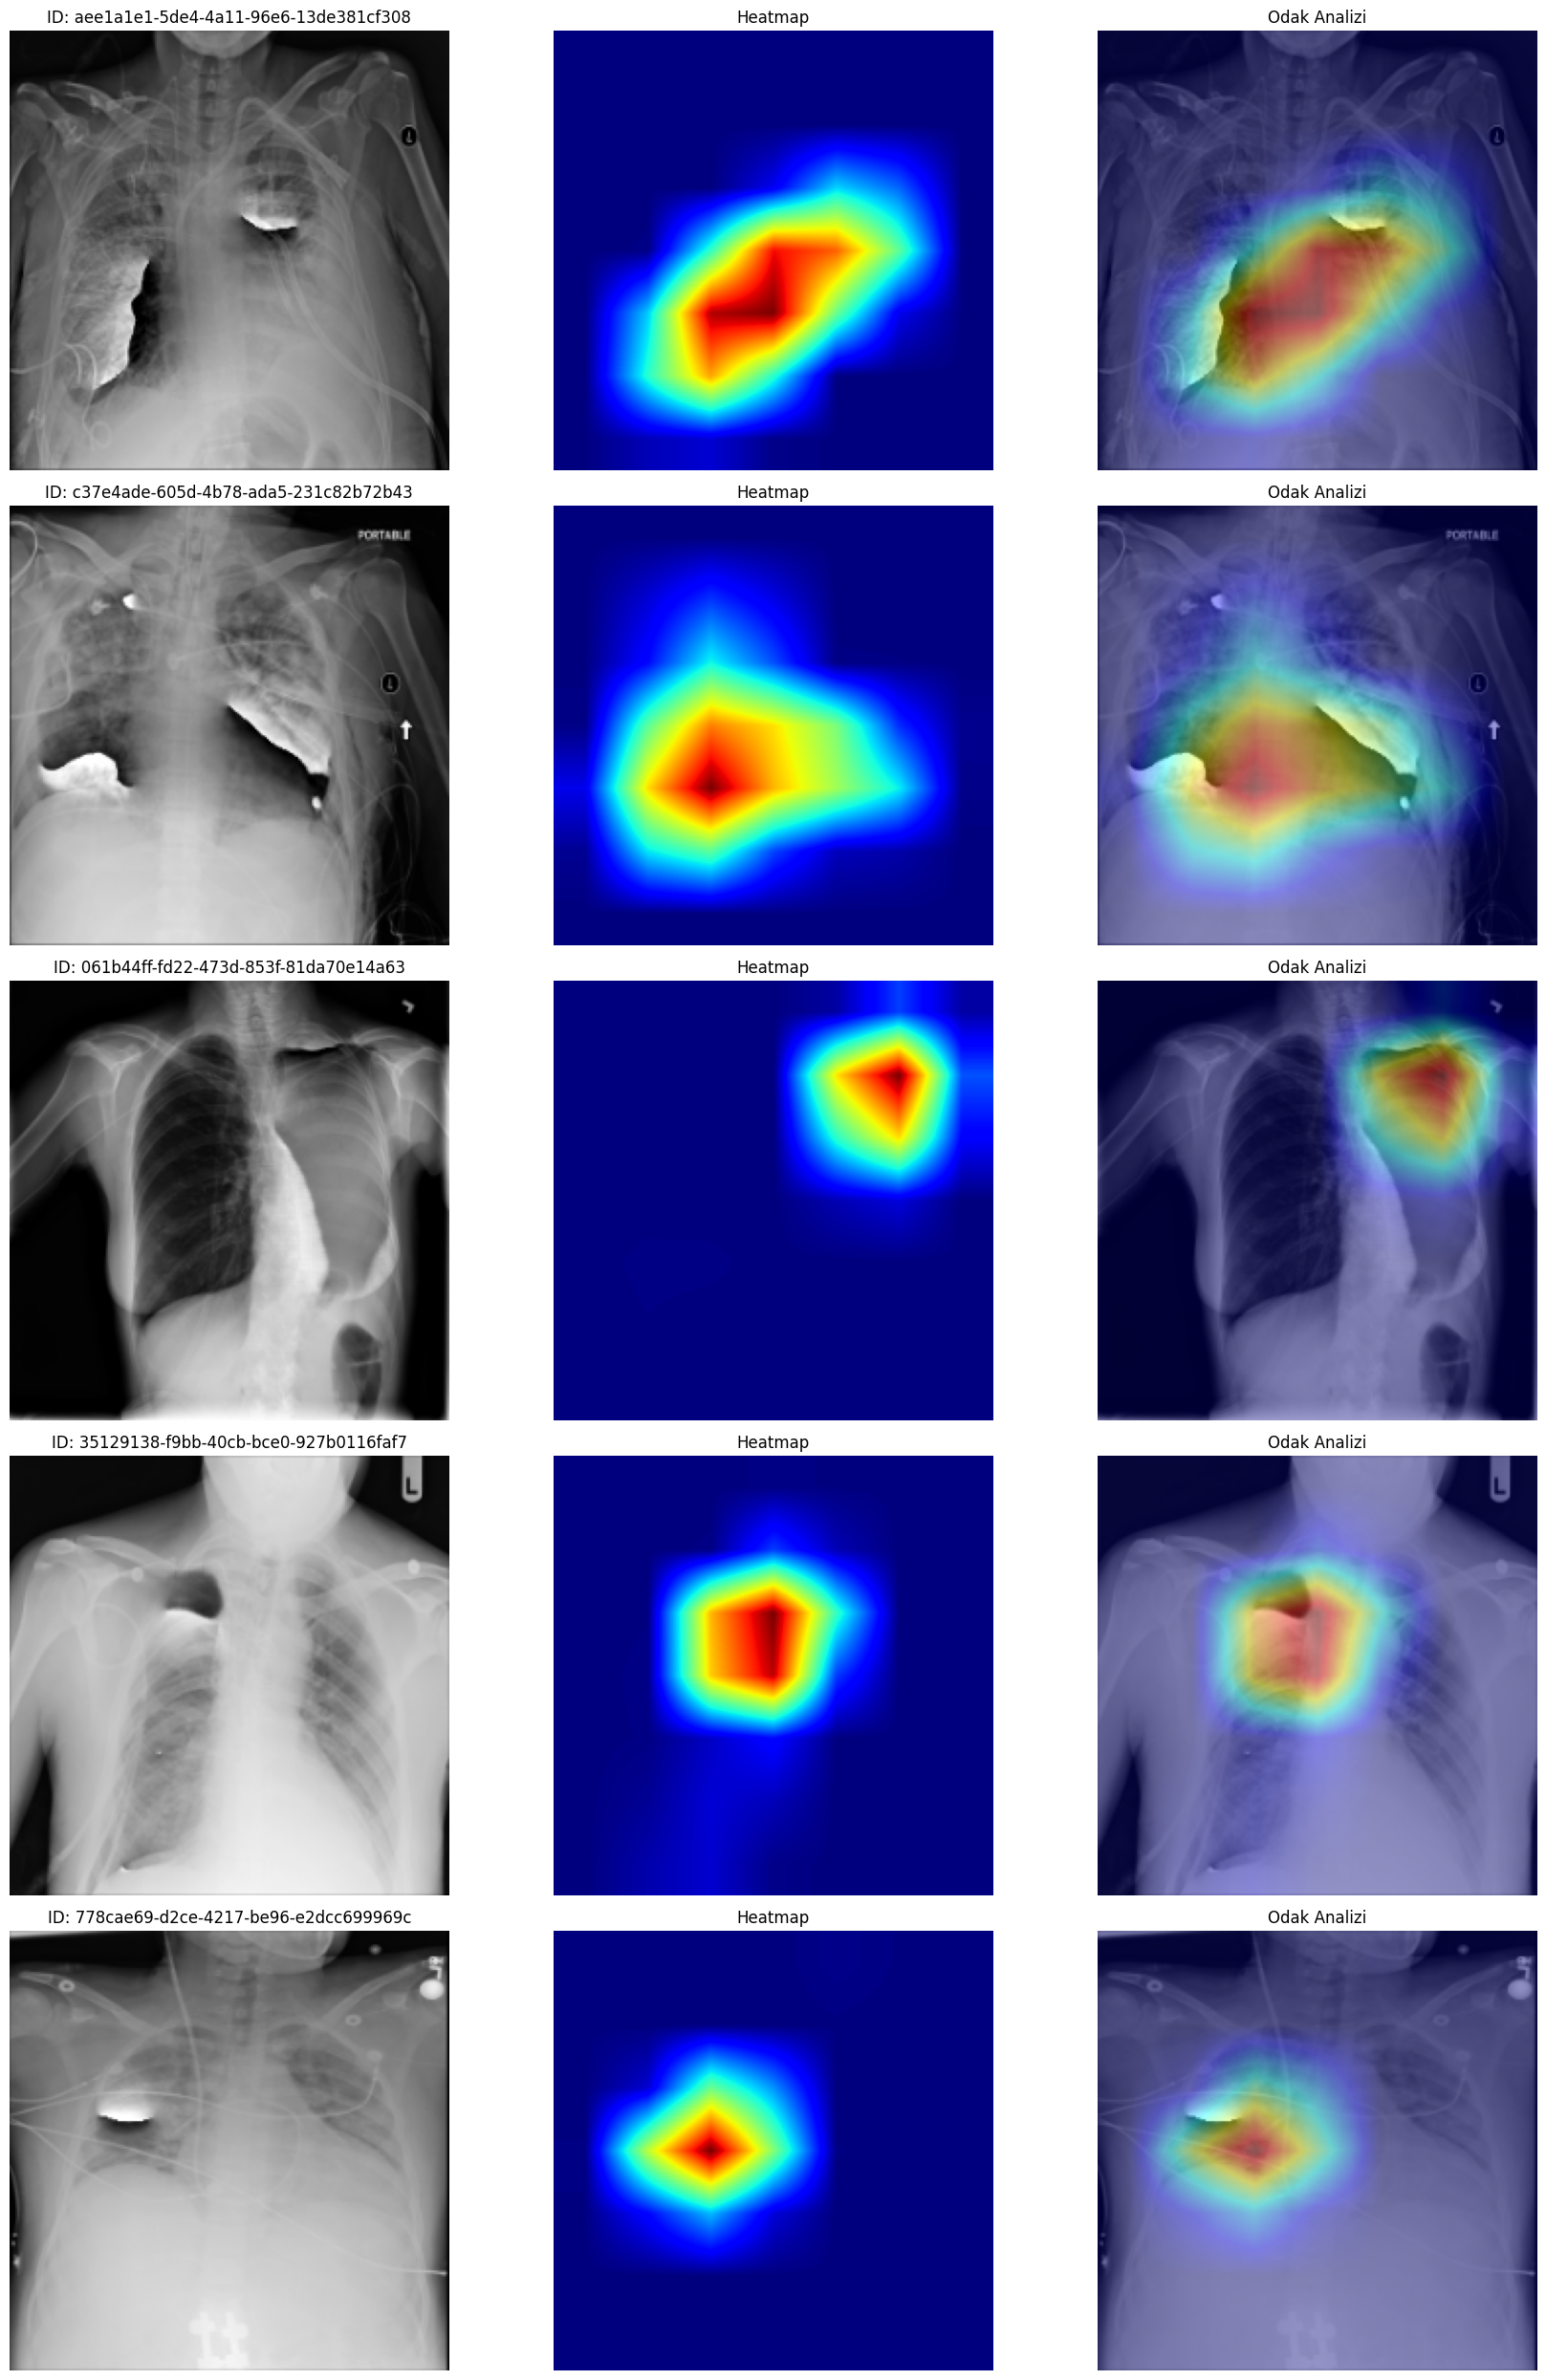

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset
import random

# ==============================================================================
# 1. KONFİGÜRASYON VE YOLLAR
# ==============================================================================
CHECKPOINT_PATH = "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON/resnet50_gan_blended/checkpoints/best.pt"
TEST_CSV_PATH   = "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"
GAN_IMAGE_ROOT  = "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 2. YARDIMCI FONKSİYONLAR VE AKILLI DATASET
# ==============================================================================
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(f"⚠️ Dosya bulunamadı: {path}")
    return img

def gray_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

class GradCAMDataset(Dataset):
    def __init__(self, csv_path, gan_root):
        self.df = pd.read_csv(csv_path)
        self.gan_root = gan_root

        # 🚨 EKRAN GÖRÜNTÜSÜNE GÖRE SÜTUN TESPİTİ
        self.id_col = "patientId" if "patientId" in self.df.columns else "sample_id"
        self.label_col = "Target" if "Target" in self.df.columns else "target"

        # Eğer sütunlar yine de bulunamazsa (farklı versiyonlar için yedek)
        if self.id_col not in self.df.columns:
            for c in ["id", "patient_id"]:
                if c in self.df.columns: self.id_col = c

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = str(row[self.id_col])
        label = int(row[self.label_col])

        # 🚨 HATA ÇÖZÜMÜ: split_name sütunu yoksa "test" klasörüne bak
        split = row["split_name"] if "split_name" in self.df.columns else "test"

        # Klasör yolu inşası
        img_path = os.path.join(self.gan_root, split, "enhanced_blended", f"{sample_id}.png")

        img = read_gray(img_path)
        img_rgb = gray_to_rgb(img)
        return self.transform(img_rgb), label, sample_id, img_rgb

# ==============================================================================
# 3. GRAD-CAM MEKANİZMASI
# ==============================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output.backward(torch.ones_like(output))

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3], keepdim=True)
        weighted_activations = self.activations * pooled_gradients

        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-10)
        return heatmap.cpu().numpy()

# ==============================================================================
# 4. ÇALIŞTIRMA VE GÖRSELLEŞTİRME
# ==============================================================================
print(f"🔄 Checkpoint yükleniyor...")
model = models.resnet50(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.45), nn.Linear(model.fc.in_features, 1))

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE).eval()
test_ds = GradCAMDataset(TEST_CSV_PATH, GAN_IMAGE_ROOT)
cam = GradCAM(model, model.layer4[-1])

# Pozitifleri (Label=1) çekelim
pos_indices = test_ds.df[test_ds.df[test_ds.label_col] == 1].index.tolist()
selected_indices = random.sample(pos_indices, min(5, len(pos_indices)))

print(f"🖼️ Görseller hazırlanıyor... (ID: {test_ds.id_col}, Etiket: {test_ds.label_col})")
fig, axes = plt.subplots(len(selected_indices), 3, figsize=(18, 5 * len(selected_indices)))

for i, idx in enumerate(selected_indices):
    img_tensor, label, s_id, raw_img = test_ds[idx]
    heatmap = cam.generate_heatmap(img_tensor.unsqueeze(0).to(DEVICE))

    heatmap_res = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

    img_vis = cv2.resize(raw_img, (224, 224)) / 255.0
    overlay = cv2.addWeighted(np.float32(img_vis), 0.6, np.float32(heatmap_color), 0.4, 0)

    curr_ax = axes[i] if len(selected_indices) > 1 else axes
    curr_ax[0].imshow(img_vis); curr_ax[0].set_title(f"ID: {s_id}"); curr_ax[0].axis('off')
    curr_ax[1].imshow(heatmap_res, cmap='jet'); curr_ax[1].set_title("Heatmap"); curr_ax[1].axis('off')
    curr_ax[2].imshow(overlay); curr_ax[2].set_title("Odak Analizi"); curr_ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_comprehensive_analysis.py"

### yeni gan blended pozitif+negatif

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v6",
  "gan_roots": {
    "gan_full": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3",
    "gan_blended": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"
  },
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "positive_class_

### gan blended deneme 2

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation.py"

DOWNSTREAM CLASSIFIER EVALUATION
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v7",
  "gan_roots": {
    "gan_full": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3",
    "gan_blended": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson"
  },
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "positive_class_

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation2.py"

SANITY CHECK (ROI ABLATION STUDY)
✅ Paths verified. Starting Patch Classifier (ROI) Training...

EXPERIMENT: resnet50_gan_blended
[INFO] Model kuruluyor: resnet50 (Dropout: 0.45)
[001/003] train_loss=0.2300 val_loss=0.1514 val_auc=0.9951 val_pr_auc=0.9819 val_f1=0.9065 val_sens=0.9917 val_spec=0.9429
[002/003] train_loss=0.1108 val_loss=0.1084 val_auc=0.9973 val_pr_auc=0.9911 val_f1=0.9352 val_sens=0.9967 val_spec=0.9608
[003/003] train_loss=0.0876 val_loss=0.0713 val_auc=0.9982 val_pr_auc=0.9924 val_f1=0.9629 val_sens=0.9933 val_spec=0.9797
Traceback (most recent call last):
  File "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation2.py", line 773, in <module>
    run_full_pipeline(CFG)
  File "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation2.py", line 755, in run_full_pipeline
    all_rows.append(train_and_evaluate_single_experiment(cfg, input_type=input_type, model_name=model_name))


### NEW

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/export_blended_label_free.py" \
  --checkpoint    "/content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/checkpoints/best.pt" \
  --train_csv     "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv" \
  --val_csv       "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv" \
  --test_csv      "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv" \
  --image_root    "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png" \
  --output_root   "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free" \
  --image_size 256 --batch_size 32 --num_workers 8 \
  --percentile 0.90 --sigmoid_temp 50.0 --blend_strength 1.0

[OK] Generator yüklendi: /content/drive/MyDrive/Spring Semester/seminar project/outputs/gan_rsna_v4_aggressive/checkpoints/best.pt
Export [train]: 100% 668/668 [30:00<00:00,  2.70s/it]
[train] 21348 görüntü kaydedildi -> /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free/train/enhanced_blended
Export [val]: 100% 84/84 [03:56<00:00,  2.81s/it]
[val] 2668 görüntü kaydedildi -> /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free/val/enhanced_blended
Export [test]: 100% 84/84 [03:58<00:00,  2.84s/it]
[test] 2668 görüntü kaydedildi -> /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free/test/enhanced_blended

[BİTTİ] Label-free blended export tamamlandı.
Output root: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free


In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/leakage_sanity_check.py"

[INFO] Etiketler permüte edildi. train pos oranı: 0.225, val pos oranı: 0.225
[INFO] Model: resnet50 (dropout=0.3)

SHUFFLED-LABEL TEST  |  input=original  model=resnet50
[ep 1/3] tr_loss=1.0758  vl_loss=1.0754  vl_auc=0.4858  (82.9s)
[ep 2/3] tr_loss=1.0733  vl_loss=1.0779  vl_auc=0.4774  (80.0s)
[ep 3/3] tr_loss=1.0720  vl_loss=1.0835  vl_auc=0.4887  (79.7s)

--------------------------------------------------------------------------------
En yüksek val AUC (shuffled): 0.4887
✓ TEMİZ: input_type=original sızdırmıyor (AUC ≈ 0.5).
[INFO] Etiketler permüte edildi. train pos oranı: 0.225, val pos oranı: 0.225
[INFO] Model: resnet50 (dropout=0.3)

SHUFFLED-LABEL TEST  |  input=global  model=resnet50
[ep 1/3] tr_loss=1.0759  vl_loss=1.0771  vl_auc=0.4586  (92.2s)
[ep 2/3] tr_loss=1.0737  vl_loss=1.0768  vl_auc=0.4835  (91.8s)
[ep 3/3] tr_loss=1.0723  vl_loss=1.0808  vl_auc=0.4789  (90.2s)

--------------------------------------------------------------------------------
En yüksek val AUC (sh

In [ ]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/run_downstream_classifier_evaluation3.py"

DOWNSTREAM CLASSIFIER (LEAK-FREE)
{
  "train_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/train_preprocessed.csv",
  "val_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/val_preprocessed.csv",
  "test_csv": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
  "original_image_root": "/content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png",
  "output_root": "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v8_leakfree",
  "gan_roots": {
    "gan_full": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3",
    "gan_blended": "/content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free"
  },
  "gan_variant_map": {
    "gan_full": "enhanced_full",
    "gan_blended": "enhanced_blended"
  },
  "po

### DEPLOYMENT

In [ ]:
!ls "/content/drive/MyDrive/Spring Semester/seminar project/data"
!ls "/content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v8_leakfree"

csv			     enhanced_images_v5_poisson  raw
enhanced_images		     guides			 README.md
enhanced_images2	     metadata			 splits
enhanced_images_v3	     preprocessed_rsna_lesion	 train
enhanced_images_v4_seamless  processed
all_results.csv			efficientnet_b0_gan_blended  resnet50_gan_full
all_results_ranked.csv		efficientnet_b0_gan_full     resnet50_global
comparison_efficientnet_b0.csv	efficientnet_b0_global	     resnet50_original
comparison_resnet50.csv		efficientnet_b0_original     r_gan_full
config.json			resnet50_gan_blended


In [ ]:
import os

DRIVE_BASE = "/content/drive/MyDrive/Spring Semester/seminar project"
print("Modeller:")
!ls "{DRIVE_BASE}/outputs/downstream_v8_leakfree" | head

print("\nVeri:")
!ls "{DRIVE_BASE}/data"

print("\nTest CSV:", os.path.exists(f"{DRIVE_BASE}/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"))
print("Backend dosyası:", os.path.exists("/root/rsna_app/backend/main.py"))
print("Frontend dosyası:", os.path.exists("/root/rsna_app/frontend/app.py"))

Modeller:
all_results.csv
all_results_ranked.csv
comparison_efficientnet_b0.csv
comparison_resnet50.csv
config.json
efficientnet_b0_gan_blended
efficientnet_b0_gan_full
efficientnet_b0_global
efficientnet_b0_original
resnet50_gan_blended

Veri:
csv			     enhanced_images_v5_poisson  raw
enhanced_images		     guides			 README.md
enhanced_images2	     metadata			 splits
enhanced_images_v3	     preprocessed_rsna_lesion	 train
enhanced_images_v4_seamless  processed

Test CSV: True
Backend dosyası: False
Frontend dosyası: False


In [ ]:
!pip install -q fastapi "uvicorn[standard]" python-multipart streamlit pyngrok pydantic opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 145.4 MB/s eta 0:00:00


In [ ]:
!pkill -f uvicorn 2>/dev/null
!pkill -f streamlit 2>/dev/null
from pyngrok import ngrok
ngrok.kill()
print("✅ Temiz")

^C
^C
✅ Temiz


In [ ]:
!grep -E "MODELS_DIR|DATA_DIR|TEST_CSV|ORIGINAL_ROOT|GAN_FULL|GAN_BLENDED" /root/rsna_app/backend/main.py | head -20

grep: /root/rsna_app/backend/main.py: No such file or directory


In [ ]:
import os

DRIVE_BASE = "/content/drive/MyDrive/Spring Semester/seminar project"

paths = {
    "MODELS_DIR":       f"{DRIVE_BASE}/outputs/downstream_v8_leakfree",
    "TEST_CSV":         f"{DRIVE_BASE}/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
    "ORIGINAL_ROOT":    f"{DRIVE_BASE}/data/preprocessed_rsna_lesion/images_png",
    "GAN_FULL_ROOT":    f"{DRIVE_BASE}/data/enhanced_images_v3",
    "GAN_BLENDED_ROOT": f"{DRIVE_BASE}/data/enhanced_images_v5_poisson",
}
for k, v in paths.items():
    print(f"{'✅' if os.path.exists(v) else '❌'}  {k}: {v}")

print("\nMODELS_DIR içeriği:")
!ls "{paths['MODELS_DIR']}" 2>/dev/null | head

print("\nİlk model klasörünün içi (best.pt nerede?):")
first_model = os.listdir(paths['MODELS_DIR'])[0] if os.path.exists(paths['MODELS_DIR']) else None
if first_model:
    !ls "{paths['MODELS_DIR']}/{first_model}"
    !ls "{paths['MODELS_DIR']}/{first_model}/checkpoints" 2>/dev/null

✅  MODELS_DIR: /content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v5_FINAL_MARATHON
✅  TEST_CSV: /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv
✅  ORIGINAL_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png
✅  GAN_FULL_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3
✅  GAN_BLENDED_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v5_poisson

MODELS_DIR içeriği:
all_results.csv
all_results_ranked.csv
comparison_efficientnet_b0.csv
comparison_resnet50.csv
config.json
efficientnet_b0_gan_blended
efficientnet_b0_gan_full
efficientnet_b0_global
efficientnet_b0_original
resnet50_gan_blended

İlk model klasörünün içi (best.pt nerede?):
checkpoints  history.csv  plots  predictions  reports
best.pt


In [ ]:
import subprocess, time
subprocess.run(["pkill", "-9", "-f", "uvicorn"])
time.sleep(2)
print("✅ Eski uvicorn kapandı")

✅ Eski uvicorn kapandı


In [ ]:
import subprocess, os, time
subprocess.run(["pkill", "-9", "-f", "uvicorn"])
subprocess.run(["pkill", "-9", "-f", "streamlit"])
time.sleep(2)

os.makedirs("/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/backend", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/frontend", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/logs", exist_ok=True)
print("✅ Hazır")

✅ Hazır


In [ ]:
!pip install -q fastapi "uvicorn[standard]" python-multipart streamlit pyngrok pydantic opencv-python-headless

In [ ]:
import sys, os, threading, time, importlib.util

BACKEND_DIR = "/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/backend"
MAIN_PY = f"{BACKEND_DIR}/main.py"

if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

# Eğer önceden yüklendiyse cache'i temizle
for m in list(sys.modules):
    if m == "backend_main": del sys.modules[m]

spec = importlib.util.spec_from_file_location("backend_main", MAIN_PY)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print(f"✅ Modeller bulundu ({len(mod.EXPERIMENTS)}):")
for mid in mod.EXPERIMENTS: print(f"   - {mid}")
print(f"✅ TEST_CSV exists: {os.path.exists(mod.TEST_CSV)}")

import uvicorn
config = uvicorn.Config(mod.app, host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)
threading.Thread(target=server.run, daemon=True).start()
time.sleep(8)

print("\n--- Health ---")
!curl -s http://localhost:8000/health

✅ Modeller bulundu (8):
   - efficientnet_b0_gan_blended
   - efficientnet_b0_gan_full
   - efficientnet_b0_global
   - efficientnet_b0_original
   - resnet50_gan_blended
   - resnet50_gan_full
   - resnet50_global
   - resnet50_original
✅ TEST_CSV exists: True
[INFO] cuda, Modeller: ['efficientnet_b0_gan_blended', 'efficientnet_b0_gan_full', 'efficientnet_b0_global', 'efficientnet_b0_original', 'resnet50_gan_blended', 'resnet50_gan_full', 'resnet50_global', 'resnet50_original'], CSV: True

--- Health ---
{"device":"cuda","models":["efficientnet_b0_gan_blended","efficientnet_b0_gan_full","efficientnet_b0_global","efficientnet_b0_original","resnet50_gan_blended","resnet50_gan_full","resnet50_global","resnet50_original"],"test_csv":true}

In [ ]:
import subprocess
# Hangi yolda log var, bul:
print(subprocess.run(["find", "/content", "-name", "streamlit.log", "-not", "-path", "*/.*"],
                     capture_output=True, text=True).stdout)

# Streamlit gerçekten ayakta mı?
!ps aux | grep -E "streamlit run" | grep -v grep
!curl -s -o /dev/null -w "Streamlit HTTP: %{http_code}\n" http://localhost:8501

KeyboardInterrupt: 

In [ ]:
import subprocess, time

FRONTEND_DIR = "/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/frontend"
LOG_PATH = "/content/drive/MyDrive/Spring Semester/seminar project/src/rsna_app/logs/streamlit.log"

log = open(LOG_PATH, "w")
streamlit = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501", "--server.address=0.0.0.0",
     "--server.headless=true", "--browser.gatherUsageStats=false"],
    cwd=FRONTEND_DIR, stdout=log, stderr=subprocess.STDOUT)
print(f"PID: {streamlit.pid}")
time.sleep(10)
!tail -8 "{LOG_PATH}"

PID: 16709
2026-05-01 22:28:15.300 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.247.145.168:8501



In [ ]:
from pyngrok import ngrok, conf

conf.get_default().auth_token = "3D8UcQ5DZrvPgUdy1ph32b2ITL5_7Uxy1qkjdXwSUeS4WcDzJ"

# Eski tünelleri kapat
for t in ngrok.get_tunnels():
    ngrok.disconnect(t.public_url)

public_url = ngrok.connect(8501, "http")
print(f"\n🚀 Arayüz: {public_url}\n")


🚀 Arayüz: NgrokTunnel: "https://harmonics-dragster-phoniness.ngrok-free.dev" -> "http://localhost:8501"



In [ ]:
# Backend logu
!tail -30 /root/rsna_app/logs/backend.log

# Streamlit logu
!tail -30 /root/rsna_app/logs/streamlit.log

In [ ]:
import requests, json

# Modelleri listele
r = requests.get("http://localhost:8000/models")
print("Modeller:")
print(json.dumps(r.json(), indent=2))

# Bir pozitif sample bul
r = requests.get("http://localhost:8000/samples", params={"label": 1, "limit": 3})
samples = r.json()
print("\nÖrnek sample'lar:", [s["sample_id"] for s in samples])

# İlkini iki modelle karşılaştır
sid = samples[0]["sample_id"]
r = requests.post("http://localhost:8000/predict_sample", json={
    "sample_id": sid,
    "model_ids": ["resnet50_global", "resnet50_gan_blended"]
})
data = r.json()
print(f"\nSample {sid} (gerçek: {data['true_label']}):")
for res in data["results"]:
    if "error" in res:
        print(f"  ❌ {res['model_id']}: {res['error']}")
    else:
        print(f"  ✅ {res['model_id']}: prob={res['probability']:.3f}, {res['prediction']}")

In [ ]:
# ============================================================================
#  RSNA LESION DEPLOYMENT — LEAK-FREE VERSION
#  Tek script: kurulum → backend → frontend → sanity test → ngrok URL
# ============================================================================

import os, sys, time, threading, subprocess, importlib.util, json

# ---------- 0. PATHS ----------
DRIVE_BASE = "/content/drive/MyDrive/Spring Semester/seminar project"
APP_BASE   = f"{DRIVE_BASE}/src/rsna_app"
BACKEND_DIR = f"{APP_BASE}/backend"
FRONTEND_DIR = f"{APP_BASE}/frontend"
LOGS_DIR     = f"{APP_BASE}/logs"

for p in [BACKEND_DIR, FRONTEND_DIR, LOGS_DIR]:
    os.makedirs(p, exist_ok=True)

# ---------- 1. CLEANUP ----------
print("[1/8] Eski süreçleri kapatıyorum...")
subprocess.run(["pkill", "-9", "-f", "uvicorn"])
subprocess.run(["pkill", "-9", "-f", "streamlit"])
try:
    from pyngrok import ngrok
    ngrok.kill()
except Exception:
    pass
time.sleep(2)
print("    ✓ Temiz")

# ---------- 2. INSTALL ----------
print("[2/8] Paketler kuruluyor (sessizce)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "fastapi", "uvicorn[standard]", "python-multipart",
                "streamlit", "pyngrok", "pydantic", "opencv-python-headless"],
               check=True)
print("    ✓ Hazır")

# ---------- 3. PATH SANITY CHECK ----------
print("[3/8] Yolları doğruluyorum...")
required_paths = {
    "MODELS_DIR":       f"{DRIVE_BASE}/outputs/downstream_v8_leakfree",
    "TEST_CSV":         f"{DRIVE_BASE}/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv",
    "ORIGINAL_ROOT":    f"{DRIVE_BASE}/data/preprocessed_rsna_lesion/images_png",
    "GAN_FULL_ROOT":    f"{DRIVE_BASE}/data/enhanced_images_v3",
    "GAN_BLENDED_ROOT": f"{DRIVE_BASE}/data/enhanced_images_v6_label_free",
}
all_ok = True
for k, v in required_paths.items():
    ok = os.path.exists(v)
    print(f"    {'✓' if ok else '✗'}  {k}: {v}")
    if not ok: all_ok = False
if not all_ok:
    raise RuntimeError("Eksik yol var. Devam etmeden kontrol et.")

models_root = required_paths["MODELS_DIR"]
n_exp = len([d for d in os.listdir(models_root) if os.path.isdir(os.path.join(models_root, d))])
print(f"    ✓ {n_exp} deney klasörü bulundu")

# ---------- 4. BACKEND main.py YAZ ----------
print("[4/8] Backend yazılıyor...")

backend_code = '''# -*- coding: utf-8 -*-
"""
backend/main.py — Leak-free deployment

Bu sürüm:
- downstream_v8_leakfree modellerini yükler
- enhanced_images_v6_label_free klasöründen blended okur
- Eğitimle uyumlu dropout=0.3 kullanır
"""

import os, io, base64, threading
from contextlib import asynccontextmanager
from typing import Dict, List, Optional

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from fastapi import FastAPI, HTTPException, UploadFile, File, Form
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from torchvision import models, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DRIVE_BASE = "/content/drive/MyDrive/Spring Semester/seminar project"

# === LEAK-FREE PATHS ===
MODELS_DIR       = f"{DRIVE_BASE}/outputs/downstream_v8_leakfree"
DATA_DIR         = f"{DRIVE_BASE}/data"
TEST_CSV         = f"{DATA_DIR}/preprocessed_rsna_lesion/metadata/test_preprocessed.csv"
ORIGINAL_ROOT    = f"{DATA_DIR}/preprocessed_rsna_lesion/images_png"
GAN_FULL_ROOT    = f"{DATA_DIR}/enhanced_images_v3"
GAN_BLENDED_ROOT = f"{DATA_DIR}/enhanced_images_v6_label_free"

INPUT_TYPE_TO_ROOT = {
    "original": ORIGINAL_ROOT,
    "global":   ORIGINAL_ROOT,
    "gan_full": GAN_FULL_ROOT,
    "gan_blended": GAN_BLENDED_ROOT,
}
GAN_SUBDIR = {"gan_full": "enhanced_full", "gan_blended": "enhanced_blended"}

# === MODEL CONFIG (training script ile birebir) ===
DROPOUT  = 0.3
IMG_SIZE = 224

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def build_resnet50():
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(m.fc.in_features, 1))
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=None)
    m.classifier = nn.Sequential(nn.Dropout(DROPOUT),
                                  nn.Linear(m.classifier[1].in_features, 1))
    return m

ARCH_BUILDERS = {
    "resnet50":         (build_resnet50,        lambda m: m.layer4[-1]),
    "efficientnet_b0":  (build_efficientnet_b0, lambda m: m.features[-1]),
}

_lock = threading.Lock()
_cache: Dict[str, dict] = {}

def discover_experiments():
    out = []
    if not os.path.isdir(MODELS_DIR):
        return out
    for name in sorted(os.listdir(MODELS_DIR)):
        full = os.path.join(MODELS_DIR, name)
        if not os.path.isdir(full):
            continue
        cands = [os.path.join(full, "best.pt"),
                 os.path.join(full, "checkpoints", "best.pt")]
        ckpt = next((c for c in cands if os.path.isfile(c)), None)
        if ckpt is None:
            continue
        arch, it = None, None
        for a in ARCH_BUILDERS:
            if name.startswith(a + "_"):
                arch, it = a, name[len(a)+1:]
                break
        if arch is None or it not in INPUT_TYPE_TO_ROOT:
            continue
        out.append({"id": name, "arch": arch, "input_type": it, "ckpt_path": ckpt})
    return out

EXPERIMENTS = {e["id"]: e for e in discover_experiments()}


class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def generate(self, x):
        self.model.zero_grad()
        out = self.model(x)
        out.backward(torch.ones_like(out))
        w = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (self.activations * w).sum(dim=1).squeeze()
        cam = F.relu(cam)
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy()


def load_experiment(exp_id):
    with _lock:
        if exp_id in _cache:
            return _cache[exp_id]
        if exp_id not in EXPERIMENTS:
            raise HTTPException(404, f"Bilinmeyen model: {exp_id}")
        exp = EXPERIMENTS[exp_id]
        builder, target_fn = ARCH_BUILDERS[exp["arch"]]
        m = builder()
        ckpt = torch.load(exp["ckpt_path"], map_location=DEVICE, weights_only=False)
        sd = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
        m.load_state_dict(sd)
        m.to(DEVICE).eval()
        _cache[exp_id] = {**exp, "model": m, "cam": GradCAM(m, target_fn(m))}
        print(f"[INFO] Loaded model: {exp_id}")
        return _cache[exp_id]


def apply_global(g):
    """Eğitimdeki global pipeline ile birebir aynı: CLAHE + unsharp(0.5, sigma=1.0)."""
    c = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    o = c.apply(g)
    b = cv2.GaussianBlur(o, (0, 0), 1.0)
    return np.clip(cv2.addWeighted(o, 1.5, b, -0.5, 0), 0, 255).astype(np.uint8)


def resolve_image_path(sid, split, it, raw):
    if it in ("original", "global"):
        for c in [raw, f"{ORIGINAL_ROOT}/{sid}.png",
                  f"{ORIGINAL_ROOT}/{split}/{sid}.png"]:
            if c and os.path.exists(c):
                return c
    else:
        c = f"{INPUT_TYPE_TO_ROOT[it]}/{split}/{GAN_SUBDIR[it]}/{sid}.png"
        if os.path.exists(c):
            return c
    raise HTTPException(404, f"Görüntü bulunamadı: {sid}/{it}/{split}")


def load_input_for_model(sid, split, it, raw):
    p = resolve_image_path(sid, split, it, raw)
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise HTTPException(500, f"Okunamadı: {p}")
    if it == "global":
        g = apply_global(g)
    return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB), p


_test_df = None
def get_test_df():
    global _test_df
    if _test_df is not None:
        return _test_df
    if not os.path.exists(TEST_CSV):
        _test_df = pd.DataFrame()
        return _test_df
    df = pd.read_csv(TEST_CSV)
    idc = next((c for c in ["patientId","sample_id","id","patient_id"] if c in df.columns), None)
    lc  = next((c for c in ["Target","target","label","class"] if c in df.columns), None)
    pc  = next((c for c in ["image_path_png","path","image_path"] if c in df.columns), None)
    df = df.rename(columns={idc:"sample_id", lc:"label"})
    df["raw_path"]  = df[pc] if pc else None
    df["split"]     = df.get("split_name", "test")
    df["sample_id"] = df["sample_id"].astype(str)
    df["label"]     = df["label"].astype(int)
    _test_df = df[["sample_id","label","raw_path","split"]].reset_index(drop=True)
    return _test_df


def to_b64(rgb):
    _, buf = cv2.imencode(".png", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    return base64.b64encode(buf.tobytes()).decode("utf-8")


def run_one(exp_id, img_rgb):
    s = load_experiment(exp_id)
    x = preprocess(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(s["model"](x)).item()
    xc = x.clone().detach().requires_grad_(True)
    h = s["cam"].generate(xc)
    h = cv2.resize(h, (IMG_SIZE, IMG_SIZE))
    hc = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET),
                      cv2.COLOR_BGR2RGB)
    iv = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    ov = cv2.addWeighted(iv, 0.6, hc, 0.4, 0)
    return {
        "model_id": exp_id,
        "arch": s["arch"],
        "input_type": s["input_type"],
        "probability": float(prob),
        "prediction": "Lesion (Pozitif)" if prob > 0.5 else "Normal (Negatif)",
        "image_b64":   to_b64(iv),
        "heatmap_b64": to_b64(hc),
        "overlay_b64": to_b64(ov),
    }


@asynccontextmanager
async def lifespan(app):
    print(f"[INFO] device={DEVICE}  models={list(EXPERIMENTS.keys())}  "
          f"csv_exists={os.path.exists(TEST_CSV)}")
    yield


app = FastAPI(lifespan=lifespan, title="RSNA Leak-Free Deploy")
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])


@app.get("/health")
def health():
    return {"device": str(DEVICE),
            "models": list(EXPERIMENTS.keys()),
            "test_csv": os.path.exists(TEST_CSV)}


@app.get("/models")
def list_models():
    return [{"id": e["id"], "arch": e["arch"], "input_type": e["input_type"]}
            for e in EXPERIMENTS.values()]


@app.get("/samples")
def list_samples(label: Optional[int] = None, limit: int = 50):
    df = get_test_df()
    if df.empty:
        return []
    if label in (0, 1):
        df = df[df["label"] == label]
    return df.head(limit).to_dict(orient="records")


class PredictRequest(BaseModel):
    sample_id: str
    model_ids: List[str]


@app.post("/predict_sample")
def predict_sample(req: PredictRequest):
    df = get_test_df()
    if df.empty:
        raise HTTPException(500, "Test CSV bulunamadı")
    row = df[df["sample_id"] == req.sample_id]
    if row.empty:
        raise HTTPException(404, f"Sample yok: {req.sample_id}")
    row = row.iloc[0]
    raw   = row["raw_path"] if pd.notna(row.get("raw_path")) else None
    split = str(row.get("split", "test"))
    res = []
    for mid in req.model_ids:
        if mid not in EXPERIMENTS:
            res.append({"model_id": mid, "error": "model not found"})
            continue
        try:
            img, used = load_input_for_model(
                req.sample_id, split, EXPERIMENTS[mid]["input_type"], raw)
            r = run_one(mid, img)
            r["used_path"] = used
            res.append(r)
        except HTTPException as e:
            res.append({"model_id": mid, "error": e.detail})
        except Exception as e:
            res.append({"model_id": mid, "error": str(e)})
    return {"sample_id": req.sample_id, "true_label": int(row["label"]), "results": res}


@app.post("/predict_upload")
async def predict_upload(file: UploadFile = File(...), model_ids: str = Form(...)):
    ids = [m.strip() for m in model_ids.split(",") if m.strip()]
    contents = await file.read()
    arr = np.frombuffer(contents, np.uint8)
    g = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise HTTPException(400, "Geçersiz görüntü")
    rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    res = []
    for mid in ids:
        if mid not in EXPERIMENTS:
            res.append({"model_id": mid, "error": "model not found"})
            continue
        it = EXPERIMENTS[mid]["input_type"]
        img_in = cv2.cvtColor(apply_global(g), cv2.COLOR_GRAY2RGB) if it == "global" else rgb
        try:
            r = run_one(mid, img_in)
            if it in ("gan_full", "gan_blended"):
                r["warning"] = "Bu model GAN-enhanced görüntü ile eğitildi; ham yüklemede distribution shift olabilir."
            res.append(r)
        except Exception as e:
            res.append({"model_id": mid, "error": str(e)})
    return {"results": res}
'''

with open(f"{BACKEND_DIR}/main.py", "w") as f:
    f.write(backend_code)
print("    ✓ backend/main.py yazıldı")

# ---------- 5. FRONTEND app.py YAZ ----------
print("[5/8] Frontend yazılıyor...")

frontend_code = '''import io, base64, requests, streamlit as st
from PIL import Image

API_URL = "http://localhost:8000"
st.set_page_config(page_title="RSNA Multi-Model", page_icon="🫁", layout="wide")
st.title("🫁 RSNA Lezyon — Çoklu Model Karşılaştırma  (Leak-Free)")

@st.cache_data(ttl=60)
def fetch_models():
    return requests.get(f"{API_URL}/models", timeout=10).json()

@st.cache_data(ttl=60)
def fetch_samples(label, limit=100):
    return requests.get(f"{API_URL}/samples",
                        params={"label": label, "limit": limit},
                        timeout=15).json()

try:
    avail = fetch_models()
except Exception as e:
    st.error(f"Backend cevap vermiyor: {e}")
    st.stop()

if not avail:
    st.error("Hiç model bulunamadı. MODELS_DIR doğru mu?")
    st.stop()

st.sidebar.header("⚙️ Modeller")
opts = {f"{m['id']}  ({m['input_type']})": m["id"] for m in avail}
chosen = st.sidebar.multiselect("Karşılaştırılacak modeller",
                                 list(opts.keys()),
                                 default=list(opts.keys())[:2])
chosen_ids = [opts[c] for c in chosen]
mode = st.sidebar.radio("Görüntü kaynağı", ["📋 Test setinden", "📤 Yükle"])

def b64img(b):
    return Image.open(io.BytesIO(base64.b64decode(b)))

def render(results, true_label=None):
    if true_label is not None:
        tag = "POZITIF" if true_label == 1 else "NEGATIF"
        st.markdown(f"**Gerçek etiket:** `{true_label}`  ({tag})")
    for r in results:
        if "error" in r:
            st.error(f"`{r['model_id']}` → {r['error']}")
            continue
        st.markdown(f"### 🧠 `{r['model_id']}`  —  {r['arch']} / {r['input_type']}")
        c0, c1 = st.columns([1, 3])
        with c0:
            (st.error if r["probability"] > 0.5 else st.success)(r["prediction"])
            st.metric("Lezyon olasılığı", f"% {r['probability']*100:.2f}")
            st.progress(min(max(r["probability"], 0.0), 1.0))
            if "warning" in r:
                st.warning(r["warning"])
        with c1:
            cc = st.columns(3)
            cc[0].image(b64img(r["image_b64"]),   caption="Input",   use_container_width=True)
            cc[1].image(b64img(r["heatmap_b64"]), caption="Grad-CAM", use_container_width=True)
            cc[2].image(b64img(r["overlay_b64"]), caption="Overlay",  use_container_width=True)
        st.markdown("---")

if mode == "📋 Test setinden":
    lbl = st.sidebar.selectbox("Etiket filtresi", [1, 0],
                               format_func=lambda x: "Pozitif" if x == 1 else "Negatif")
    samples = fetch_samples(lbl, 100)
    if not samples:
        st.warning("Sample bulunamadı")
        st.stop()
    sid = st.selectbox(f"Sample seç ({len(samples)})",
                        [s["sample_id"] for s in samples])
    if st.button("🚀 Karşılaştır", type="primary", disabled=not chosen_ids):
        with st.spinner("Çalışıyor..."):
            r = requests.post(f"{API_URL}/predict_sample",
                              json={"sample_id": sid, "model_ids": chosen_ids},
                              timeout=180)
        if r.status_code == 200:
            d = r.json()
            render(d["results"], d["true_label"])
        else:
            st.error(f"{r.status_code}: {r.text}")
else:
    up = st.file_uploader("Röntgen yükle", type=["png", "jpg", "jpeg"])
    if up:
        st.image(Image.open(up), width=300)
    if st.button("🚀 Karşılaştır", type="primary",
                 disabled=(up is None or not chosen_ids)):
        with st.spinner("Çalışıyor..."):
            files = {"file": (up.name, up.getvalue(), up.type or "image/png")}
            r = requests.post(f"{API_URL}/predict_upload",
                              data={"model_ids": ",".join(chosen_ids)},
                              files=files, timeout=180)
        if r.status_code == 200:
            render(r.json()["results"])
        else:
            st.error(f"{r.status_code}: {r.text}")
'''

with open(f"{FRONTEND_DIR}/app.py", "w") as f:
    f.write(frontend_code)
print("    ✓ frontend/app.py yazıldı")

# ---------- 6. BACKEND START ----------
print("[6/8] Backend başlatılıyor...")

if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)
for m in list(sys.modules):
    if m == "backend_main":
        del sys.modules[m]

spec = importlib.util.spec_from_file_location("backend_main", f"{BACKEND_DIR}/main.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print(f"    ✓ {len(mod.EXPERIMENTS)} model registered:")
for mid in mod.EXPERIMENTS:
    print(f"        - {mid}")

import uvicorn
config = uvicorn.Config(mod.app, host="0.0.0.0", port=8000, log_level="warning")
server = uvicorn.Server(config)
threading.Thread(target=server.run, daemon=True).start()
time.sleep(8)

import requests
try:
    h = requests.get("http://localhost:8000/health", timeout=10).json()
    print(f"    ✓ Backend health: {h}")
except Exception as e:
    raise RuntimeError(f"Backend ayağa kalkmadı: {e}")

# ---------- 7. SANITY TEST (probability sağlık kontrolü) ----------
print("[7/8] Sanity test (sızıntı kontrolü)...")

try:
    pos = requests.get("http://localhost:8000/samples",
                        params={"label": 1, "limit": 5}).json()
    neg = requests.get("http://localhost:8000/samples",
                        params={"label": 0, "limit": 5}).json()

    test_model = "resnet50_gan_blended"
    if test_model not in mod.EXPERIMENTS:
        test_model = list(mod.EXPERIMENTS.keys())[0]
        print(f"    ! resnet50_gan_blended yok, {test_model} ile test ediliyor")

    pos_probs, neg_probs = [], []
    for s in pos:
        r = requests.post("http://localhost:8000/predict_sample",
                          json={"sample_id": s["sample_id"],
                                "model_ids": [test_model]}, timeout=60).json()
        if r["results"] and "probability" in r["results"][0]:
            pos_probs.append(r["results"][0]["probability"])
    for s in neg:
        r = requests.post("http://localhost:8000/predict_sample",
                          json={"sample_id": s["sample_id"],
                                "model_ids": [test_model]}, timeout=60).json()
        if r["results"] and "probability" in r["results"][0]:
            neg_probs.append(r["results"][0]["probability"])

    print(f"    Pozitif sample probs: {[f'{p:.3f}' for p in pos_probs]}")
    print(f"    Negatif sample probs: {[f'{p:.3f}' for p in neg_probs]}")

    if pos_probs and neg_probs:
        mean_pos = sum(pos_probs) / len(pos_probs)
        mean_neg = sum(neg_probs) / len(neg_probs)
        print(f"    Mean pos = {mean_pos:.3f}  Mean neg = {mean_neg:.3f}")
        if mean_pos > 0.95 and mean_neg < 0.05:
            print("    ⚠ ŞÜPHELİ: Mean'ler aşırı uçta — sızıntı belirtisi olabilir.")
        elif mean_pos > mean_neg:
            print("    ✓ Sağlıklı dağılım: pozitif > negatif (beklendiği gibi)")
        else:
            print("    ⚠ pos < neg — model ters çalışıyor olabilir!")
except Exception as e:
    print(f"    ! Sanity test başarısız: {e}")

# ---------- 8. FRONTEND + NGROK ----------
print("[8/8] Frontend ve ngrok başlatılıyor...")

LOG_PATH = f"{LOGS_DIR}/streamlit.log"
log = open(LOG_PATH, "w")
streamlit = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501", "--server.address=0.0.0.0",
     "--server.headless=true", "--browser.gatherUsageStats=false"],
    cwd=FRONTEND_DIR, stdout=log, stderr=subprocess.STDOUT)
print(f"    Streamlit PID: {streamlit.pid}")
time.sleep(10)

# Streamlit kontrol
import requests
try:
    code = requests.get("http://localhost:8501", timeout=5).status_code
    print(f"    ✓ Streamlit HTTP {code}")
except Exception:
    print("    ! Streamlit'e ulaşılamıyor, log son 8 satır:")
    subprocess.run(["tail", "-8", LOG_PATH])

# Ngrok
NGROK_TOKEN = os.environ.get("NGROK_TOKEN")
if not NGROK_TOKEN:
    try:
        from google.colab import userdata
        NGROK_TOKEN = userdata.get("NGROK_TOKEN")
    except Exception:
        pass

if not NGROK_TOKEN:
    print("\n" + "="*70)
    print("    ⚠ NGROK_TOKEN tanımlı değil!")
    print("    Colab Secrets'a ekle (sol panel → 🔑 Secrets) veya:")
    print("        os.environ['NGROK_TOKEN'] = 'YOUR_TOKEN'")
    print("    Sonra bu cell'i tekrar çalıştır.")
    print("="*70)
else:
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_TOKEN
    for t in ngrok.get_tunnels():
        ngrok.disconnect(t.public_url)
    public_url = ngrok.connect(8501, "http")
    print("\n" + "="*70)
    print(f"    🚀 ARAYÜZ HAZIR:  {public_url}")
    print("="*70)

print("\n[BİTTİ] Deployment ayakta. URL'yi tarayıcıda aç.")

[1/8] Eski süreçleri kapatıyorum...
    ✓ Temiz
[2/8] Paketler kuruluyor (sessizce)...
    ✓ Hazır
[3/8] Yolları doğruluyorum...
    ✓  MODELS_DIR: /content/drive/MyDrive/Spring Semester/seminar project/outputs/downstream_v8_leakfree
    ✓  TEST_CSV: /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/metadata/test_preprocessed.csv
    ✓  ORIGINAL_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/preprocessed_rsna_lesion/images_png
    ✓  GAN_FULL_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v3
    ✓  GAN_BLENDED_ROOT: /content/drive/MyDrive/Spring Semester/seminar project/data/enhanced_images_v6_label_free
    ✓ 8 deney klasörü bulundu
[4/8] Backend yazılıyor...
    ✓ backend/main.py yazıldı
[5/8] Frontend yazılıyor...
    ✓ frontend/app.py yazıldı
[6/8] Backend başlatılıyor...
    ✓ 8 model registered:
        - efficientnet_b0_gan_blended
        - efficientnet_b0_gan_full
        - efficientnet_b0

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    Pozitif sample probs: ['0.956', '0.628', '0.964', '0.975', '0.429']
    Negatif sample probs: ['0.151', '0.066', '0.550', '0.026', '0.292']
    Mean pos = 0.790  Mean neg = 0.217
    ✓ Sağlıklı dağılım: pozitif > negatif (beklendiği gibi)
[8/8] Frontend ve ngrok başlatılıyor...
    Streamlit PID: 12051
    ✓ Streamlit HTTP 200

    🚀 ARAYÜZ HAZIR:  NgrokTunnel: "https://harmonics-dragster-phoniness.ngrok-free.dev" -> "http://localhost:8501"

[BİTTİ] Deployment ayakta. URL'yi tarayıcıda aç.


### analysis

In [ ]:
# 1. Script'i Drive'a koy
# /content/drive/MyDrive/Spring Semester/seminar project/scripts/paper_finalize.py

# 2. Çalıştır (5-10 dk sürer)
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/paper_finalize.py"


################################################################################
PAPER FINALIZATION ANALYSIS
Output: /content/drive/MyDrive/Spring Semester/seminar project/outputs/paper_analysis
################################################################################

STATISTICAL SIGNIFICANCE TESTS — resnet50
Reference: gan_blended

   model              comparison  delta_auc  auc_ci_lower  auc_ci_upper  auc_pval auc_significant  mcnemar_pval mcnemar_significant  discordant_b  discordant_c
resnet50 gan_blended vs original    -0.0199       -0.0289       -0.0111    0.0005               ✓        0.2018                   —           137           160
resnet50   gan_blended vs global    -0.0149       -0.0241       -0.0064    0.0005               ✓        0.0013                   ✓           128           186
resnet50 gan_blended vs gan_full    -0.0006       -0.0082        0.0068    0.8640               —        0.1310                   —           104           128

STATISTICAL SIG

In [1]:
!python "/content/drive/MyDrive/Spring Semester/seminar project/scripts/paper_extras.py"


################################################################################
PAPER EXTRAS ANALYSIS — Output: /content/drive/MyDrive/Spring Semester/seminar project/outputs/paper_analysis_extras
################################################################################

DECISION CURVE ANALYSIS — resnet50
  Saved: /content/drive/MyDrive/Spring Semester/seminar project/outputs/paper_analysis_extras/dca_resnet50.png

Net Benefit at p_t = 0.20 (screening) and p_t = 0.40 (triage):
  original         NB(0.20)=0.1207  NB(0.40)=0.0529
  global           NB(0.20)=0.1345  NB(0.40)=0.0620
  gan_full         NB(0.20)=0.1326  NB(0.40)=0.0725
  gan_blended      NB(0.20)=0.1251  NB(0.40)=0.0512

SUBGROUP (DIFFICULTY) ANALYSIS — resnet50
Reference for difficulty: original
  Easy (|p-0.5|>0.4):    n=924
  Medium (0.2<|p-0.5|<=0.4): n=1036
  Hard (|p-0.5|<=0.2):   n=708

   model      method subgroup    n  n_pos    AUC  Accuracy
resnet50    original     easy  924    241 0.9626    0.9318
resnet